In [ ]:
!pip install data_load

ERROR: Could not find a version that satisfies the requirement data_load (from versions: none)
ERROR: No matching distribution found for data_load


In [ ]:
gpu_info = !nvidia-smi
gpu_info = '\n'.join(gpu_info)
if gpu_info.find('failed') >= 0:
  print('Not connected to a GPU')
else:
  print(gpu_info)

Wed Apr  9 13:32:18 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA L4                      Off |   00000000:00:03.0 Off |                    0 |
| N/A   43C    P8             12W /   72W |       0MiB /  23034MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

# Data Unzipping

In [1]:
import os
import zipfile
import torch
import shutil
from pathlib import Path

def setup_gpu():
    """
    Check if GPU is available and set it up for use

    Returns:
        bool: True if GPU is available, False otherwise
    """
    # Check if CUDA (GPU) is available
    if torch.cuda.is_available():
        device = torch.device("cuda")
        print(f"GPU is available: {torch.cuda.get_device_name(0)}")
        print(f"Number of GPUs: {torch.cuda.device_count()}")

        # Print some additional GPU information
        print(f"Current GPU device: {torch.cuda.current_device()}")
        print(f"GPU memory allocated: {torch.cuda.memory_allocated(0) / 1024**2:.2f} MB")
        print(f"GPU memory cached: {torch.cuda.memory_reserved(0) / 1024**2:.2f} MB")

        return True
    else:
        device = torch.device("cpu")
        print("GPU not available, using CPU instead.")
        return False

In [ ]:


def load_and_extract_zip(zip_path, extract_to=None, remove_zip=False):
    """
    Load a zip file from the specified path and extract its contents

    Args:
        zip_path (str): Path to the zip file
        extract_to (str, optional): Path to extract the contents to. If None,
                                    contents are extracted to the same directory as zip file.
        remove_zip (bool, optional): Whether to remove the zip file after extraction. Default is False.

    Returns:
        str: Path to the extracted directory
    """
    # Make sure the zip file exists
    zip_path = Path(zip_path)
    if not zip_path.exists():
        raise FileNotFoundError(f"The zip file at {zip_path} does not exist.")

    # Determine extraction path
    if extract_to is None:
        extract_to = zip_path.parent
    else:
        extract_to = Path(extract_to)
        os.makedirs(extract_to, exist_ok=True)

    print(f"Extracting zip file from: {zip_path}")
    print(f"Extracting to: {extract_to}")

    # Extract the zip file
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        total_files = len(zip_ref.infolist())
        print(f"Total files in archive: {total_files}")

        # Extract all files
        zip_ref.extractall(extract_to)

    # Get the extracted folder name
    # Usually the main folder in a zip has the same name as the zip without the extension
    extracted_folder = extract_to / zip_path.stem
    if not extracted_folder.exists():
        # If the extracted folder doesn't match the zip name, just return the extraction path
        extracted_folder = extract_to

    print(f"Extraction completed. Files extracted to: {extracted_folder}")

    # Remove the zip file if requested
    if remove_zip:
        os.remove(zip_path)
        print(f"Zip file removed: {zip_path}")

    return str(extracted_folder)



In [ ]:
if __name__ == "__main__":
    has_gpu = setup_gpu()
    zip_path = "/content/drive/MyDrive/ML Projects/chest_xray_classf/Dataset/chest-x-ray-dataset-with-lung-segmentation-1.0.0.zip"
    dataset_path = load_and_extract_zip(zip_path)

    print(f"Dataset is ready at: {dataset_path}")
    print(f"Using GPU: {has_gpu}")

GPU is available: NVIDIA L4
Number of GPUs: 1
Current GPU device: 0
GPU memory allocated: 0.00 MB
GPU memory cached: 0.00 MB
Extracting zip file from: /content/drive/MyDrive/ML Projects/chest_xray_classf/Dataset/chest-x-ray-dataset-with-lung-segmentation-1.0.0.zip
Extracting to: /content/drive/MyDrive/ML Projects/chest_xray_classf/Dataset
Total files in archive: 486654
Extraction completed. Files extracted to: /content/drive/MyDrive/ML Projects/chest_xray_classf/Dataset/chest-x-ray-dataset-with-lung-segmentation-1.0.0
Dataset is ready at: /content/drive/MyDrive/ML Projects/chest_xray_classf/Dataset/chest-x-ray-dataset-with-lung-segmentation-1.0.0
Using GPU: True


# Label Preparations

In [ ]:
import pandas as pd
import os
import torch
import numpy as np
from pathlib import Path


def process_csv_for_multilabel(csv_path, output_path):
    """
    Process CSV file for multilabel classification:
    1. Remove rows with -1 values (representing uncertainty)
    2. Replace empty values with 0
    3. Save the processed CSV

    Args:
        csv_path (str): Path to the CSV file
        output_path (str): Path to save the processed CSV file

    Returns:
        pd.DataFrame: Processed DataFrame
    """
    print(f"Reading CSV from: {csv_path}")

    # Read the CSV file
    try:
        # Use pandas with GPU acceleration if available via cuDF
        # First check if we can use RAPIDS cuDF for GPU-accelerated pandas operations
        try:
            import cudf
            print("RAPIDS cuDF is available. Using GPU acceleration for data processing.")
            df = cudf.read_csv(csv_path)
            using_gpu_pandas = True
        except (ImportError, ModuleNotFoundError):
            print("RAPIDS cuDF not available. Using standard pandas (CPU-based).")
            df = pd.read_csv(csv_path)
            using_gpu_pandas = False
    except Exception as e:
        print(f"Error reading CSV with GPU acceleration: {e}")
        print("Falling back to standard pandas...")
        df = pd.read_csv(csv_path)
        using_gpu_pandas = False

    # Convert cuDF DataFrame to pandas if needed for compatibility with all operations
    if using_gpu_pandas:
        try:
            df_pandas = df.to_pandas()
            print("Converted cuDF DataFrame to pandas for compatibility.")
        except:
            df_pandas = df
    else:
        df_pandas = df

    # Print basic information about the dataset
    print(f"Original DataFrame shape: {df_pandas.shape}")
    print("Columns in the dataset:")
    print(df_pandas.columns.tolist())

    # Print some basic stats
    print("\nBasic statistics before processing:")
    print(f"Number of rows: {len(df_pandas)}")

    # Count missing values in each column
    missing_values = df_pandas.isnull().sum()
    print("\nMissing values in each column:")
    print(missing_values)

    # Count -1 values in each column (representing uncertainty)
    columns_with_minus_one = []
    for col in df_pandas.columns:
        if df_pandas[col].dtype in [np.int64, np.float64]:  # Only check numeric columns
            minus_one_count = (df_pandas[col] == -1).sum()
            if minus_one_count > 0:
                columns_with_minus_one.append((col, minus_one_count))

    print("\nColumns with -1 values (uncertainty):")
    for col, count in columns_with_minus_one:
        print(f"{col}: {count} occurrences")

    # Identify label columns (assuming they are after the image path column)
    # This is an assumption - you may need to adjust based on your actual CSV structure
    try:
        # Try to find the 'Path' column or similar
        path_col = [col for col in df_pandas.columns if 'path' in col.lower() or 'file' in col.lower()]
        if path_col:
            path_col = path_col[0]
            # Columns after the path column are likely label columns
            non_label_cols = [path_col]
        else:
            # If no path column is found, assume the first column is not a label
            path_col = df_pandas.columns[0]
            non_label_cols = [path_col]

        label_cols = [col for col in df_pandas.columns if col not in non_label_cols]
        print(f"\nIdentified label columns: {label_cols}")

    except Exception as e:
        print(f"Error identifying label columns: {e}")
        # As a fallback, assume all columns except the first one are labels
        path_col = df_pandas.columns[0]
        label_cols = df_pandas.columns[1:]
        print(f"Fallback - using all columns except the first as labels: {label_cols}")

    # Step 1: Drop rows with -1 in any label column
    original_row_count = len(df_pandas)

    # Create a mask for rows to drop (rows with -1 in any label column)
    rows_with_minus_one = df_pandas[label_cols].eq(-1).any(axis=1)

    # Drop the rows with -1
    df_pandas = df_pandas[~rows_with_minus_one]

    print(f"\nRemoved {original_row_count - len(df_pandas)} rows with -1 values")
    print(f"Remaining rows: {len(df_pandas)}")

    # Step 2: Replace empty values with 0
    df_pandas[label_cols] = df_pandas[label_cols].fillna(0)

    # Report the changes
    print("\nAfter processing:")
    print(f"DataFrame shape: {df_pandas.shape}")

    # Check if all missing values are handled
    missing_after = df_pandas[label_cols].isnull().sum().sum()
    print(f"Missing values after processing: {missing_after}")

    # Ensure the output directory exists
    output_dir = os.path.dirname(output_path)
    if output_dir and not os.path.exists(output_dir):
        os.makedirs(output_dir, exist_ok=True)
        print(f"Created directory: {output_dir}")

    # Save the processed DataFrame
    df_pandas.to_csv(output_path, index=False)
    print(f"Processed CSV saved to: {output_path}")

    # Print sample rows
    print("\nSample of processed data:")
    print(df_pandas.head())

    return df_pandas



In [ ]:
import os

if __name__ == "__main__":
    # Check if GPU is available and set it up
    has_gpu = setup_gpu()
    print(f"GPU available: {has_gpu}")
    if has_gpu:
        print("Using GPU for operations that support it.")

        # Try to set PyTorch to use GPU tensors by default
        try:
            torch.set_default_tensor_type('torch.cuda.FloatTensor')
            print("PyTorch set to use CUDA tensors by default.")
        except Exception as e:
            print(f"Error setting PyTorch default tensor type: {e}")

    # Define paths
    input_csv_path = "/content/drive/MyDrive/ML Projects/chest_xray_classf/Dataset/chest-x-ray-dataset-with-lung-segmentation-1.0.0/CXLSeg-segmented.csv"
    output_directory = "/content/drive/MyDrive/ML Projects/chest_xray_classf/processed_data"
    output_path = os.path.join(output_directory, "processed_labels.csv")

    # Create the directory only if it doesn't exist
    if not os.path.exists(output_directory):
        os.makedirs(output_directory)
        print(f"Created output directory: {output_directory}")
    else:
        print(f"Output directory already exists: {output_directory}")

    # Process the CSV file
    processed_df = process_csv_for_multilabel(input_csv_path, output_path)

    print("\nCSV processing completed successfully!")
    print(f"Processed CSV saved to Google Drive at: {output_path}")

    if has_gpu:
        print("GPU was used for compatible operations.")
        print("GPU is ready for your subsequent machine learning tasks.")

        # Show GPU memory usage
        if torch.cuda.is_available():
            print(f"GPU memory allocated: {torch.cuda.memory_allocated(0) / 1024**2:.2f} MB")
            print(f"GPU memory cached: {torch.cuda.memory_reserved(0) / 1024**2:.2f} MB")

            # Optional: clean up GPU memory
            torch.cuda.empty_cache()
            print("GPU cache cleared.")


GPU is available: NVIDIA L4
Number of GPUs: 1
Current GPU device: 0
GPU memory allocated: 0.00 MB
GPU memory cached: 0.00 MB
GPU available: True
Using GPU for operations that support it.
PyTorch set to use CUDA tensors by default.
Output directory already exists: /content/drive/MyDrive/ML Projects/chest_xray_classf/processed_data
Reading CSV from: /content/drive/MyDrive/ML Projects/chest_xray_classf/Dataset/chest-x-ray-dataset-with-lung-segmentation-1.0.0/CXLSeg-segmented.csv
RAPIDS cuDF is available. Using GPU acceleration for data processing.
Converted cuDF DataFrame to pandas for compatibility.
Original DataFrame shape: (243324, 18)
Columns in the dataset:
['dicom_id', 'subject_id', 'study_id', 'DicomPath', 'Atelectasis', 'Cardiomegaly', 'Consolidation', 'Edema', 'Enlarged Cardiomediastinum', 'Fracture', 'Lung Lesion', 'Lung Opacity', 'No Finding', 'Pleural Effusion', 'Pleural Other', 'Pneumonia', 'Pneumothorax', 'Support Devices']

Basic statistics before processing:
Number of rows

# Images Reading and Label Maping

In [ ]:
import os
import pandas as pd
import numpy as np
import torch
from pathlib import Path
import cv2
import base64
from io import BytesIO
from PIL import Image
from tqdm import tqdm
import io

def load_and_encode_image(image_path, target_size=(224, 224), return_array=False):
    """
    Load an image and encode it as base64 string or return as numpy array

    Args:
        image_path (str): Path to the image
        target_size (tuple): Size to resize the image to
        return_array (bool): If True, return numpy array instead of base64 string

    Returns:
        str or np.array: Base64 encoded image or numpy array
    """
    try:
        # Try using OpenCV with GPU acceleration if available
        try:
            if torch.cuda.is_available():
                # OpenCV with CUDA
                img = cv2.imread(image_path)
                if img is None:
                    raise ValueError(f"Failed to read image with OpenCV: {image_path}")

                # Convert from BGR to RGB
                img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

                # Resize
                img = cv2.resize(img, target_size)

                if return_array:
                    return img

                # Encode to base64
                _, buffer = cv2.imencode('.jpg', img)
                img_str = base64.b64encode(buffer).decode('utf-8')
                return img_str
        except:
            # Fall back to PIL
            with Image.open(image_path) as img:
                img = img.resize(target_size)
                if return_array:
                    return np.array(img)

                # Save to buffer and encode to base64
                buffer = BytesIO()
                img.save(buffer, format="JPEG")
                img_str = base64.b64encode(buffer.getvalue()).decode('utf-8')
                return img_str
    except Exception as e:
        print(f"Error processing image {image_path}: {e}")
        return None

def explore_directory(base_dir, levels=3, max_per_level=3):
    """
    Explore a directory structure to find the actual path pattern

    Args:
        base_dir (str): Base directory to start from
        levels (int): How many levels deep to explore
        max_per_level (int): Maximum number of items to show per level
    """
    if not os.path.exists(base_dir):
        print(f"Directory {base_dir} does not exist")
        return

    print(f"Exploring directory: {base_dir}")

    def _explore(current_dir, current_level=0):
        if current_level >= levels:
            return

        try:
            items = os.listdir(current_dir)
            if current_level == 0:
                print(f"Top level items in {current_dir}:")
            else:
                print(f"{'  ' * current_level}Items in {os.path.basename(current_dir)}:")

            for i, item in enumerate(items[:max_per_level]):
                item_path = os.path.join(current_dir, item)
                is_dir = os.path.isdir(item_path)
                print(f"{'  ' * (current_level+1)}{'[DIR]' if is_dir else '[FILE]'} {item}")

                if is_dir:
                    _explore(item_path, current_level + 1)

            if len(items) > max_per_level:
                print(f"{'  ' * (current_level+1)}... and {len(items) - max_per_level} more items")
        except Exception as e:
            print(f"Error exploring {current_dir}: {e}")

    _explore(base_dir)

def process_images_and_labels(labels_csv_path, images_base_path, output_csv_path, include_images=True, batch_size=1000):
    """
    Process images and their corresponding labels

    Args:
        labels_csv_path (str): Path to the processed labels CSV
        images_base_path (str): Base path to the images folder
        output_csv_path (str): Path to save the output CSV with image paths and labels
        include_images (bool): Whether to include the actual images (encoded as base64) in the CSV
                              Default is now True as requested by user
        batch_size (int): Number of images to process at once to avoid memory issues

    Returns:
        pd.DataFrame: DataFrame with image column and label columns
    """
    print(f"Loading labels from: {labels_csv_path}")

    # Load the labels
    try:
        # Try with GPU acceleration if available
        try:
            import cudf
            df_labels = cudf.read_csv(labels_csv_path)
            print("Using GPU-accelerated cuDF for reading CSV")
            df_labels = df_labels.to_pandas()  # Convert to pandas for compatibility
        except (ImportError, ModuleNotFoundError):
            df_labels = pd.read_csv(labels_csv_path)
            print("Using standard pandas for reading CSV")
    except Exception as e:
        print(f"Error loading labels: {e}")
        df_labels = pd.read_csv(labels_csv_path)

    print(f"Loaded {len(df_labels)} label records")

    # Check if DicomPath column exists
    if 'DicomPath' not in df_labels.columns:
        raise ValueError("DicomPath column not found in the labels CSV")

    # Explore the directory structure to find the actual location of files
    print("\nExploring the directory structure to help find the images:")
    explore_directory(images_base_path)

    # Build a list of potential base paths to try
    potential_paths = [
        images_base_path,
        os.path.join(images_base_path, 'files'),
        os.path.dirname(images_base_path)
    ]

    # Add more potential paths if needed
    if os.path.exists(os.path.join(images_base_path, 'files')):
        print(f"\nFound 'files' directory at {os.path.join(images_base_path, 'files')}")
        files_dir = os.path.join(images_base_path, 'files')
        # Explore the files directory to see its structure
        explore_directory(files_dir)

    # Print some sample paths from the CSV to understand the structure
    print("\nSample paths from the CSV:")
    for i, path in enumerate(df_labels['DicomPath'].head(3).tolist()):
        print(f"  {i+1}. {path}")

    # Function to fix paths - try multiple base paths
    def create_image_paths_for_base(base_path, dicom_path):
        if pd.isna(dicom_path):
            return None

        # Try direct join
        path1 = os.path.join(base_path, dicom_path)

        # Try removing 'files/' prefix if it exists
        path2 = None
        if dicom_path.startswith('files/'):
            path2 = os.path.join(base_path, dicom_path[6:])

        # Try adding 'files/' if not present
        path3 = None
        if not dicom_path.startswith('files/'):
            path3 = os.path.join(base_path, 'files', dicom_path)

        return [p for p in [path1, path2, path3] if p is not None]

    # Try all potential base paths to find working image paths
    print("\nTrying different path combinations to find the images:")

    # Test first few rows with different path combinations
    working_paths = []
    test_rows = min(5, len(df_labels))

    for base_path in potential_paths:
        if not os.path.exists(base_path):
            print(f"Skipping non-existent base path: {base_path}")
            continue

        print(f"Testing with base path: {base_path}")
        paths_found = 0

        for i in range(test_rows):
            dicom_path = df_labels.iloc[i]['DicomPath']
            potential_file_paths = create_image_paths_for_base(base_path, dicom_path)

            for path in potential_file_paths:
                exists = os.path.exists(path)
                if exists:
                    paths_found += 1
                    working_paths.append((base_path, i, path, True))
                    print(f"  FOUND: {path}")
                    break
                else:
                    working_paths.append((base_path, i, path, False))

    # Determine the best base path based on test results
    base_path_success_count = {}
    for base_path, _, _, success in working_paths:
        if success:
            base_path_success_count[base_path] = base_path_success_count.get(base_path, 0) + 1

    best_base_path = None
    max_success = 0
    for base_path, count in base_path_success_count.items():
        if count > max_success:
            max_success = count
            best_base_path = base_path

    # If we found a good base path, use it
    if best_base_path:
        print(f"\nFound working base path: {best_base_path} (matched {max_success} files)")
        images_base_path = best_base_path

        # Determine the best path creation strategy
        best_strategy = 1  # Default: direct join

        # Check if removing 'files/' or adding 'files/' worked better
        remove_files_prefix_worked = any(
            success for base, _, path, success in working_paths
            if base == best_base_path and success and not path.startswith(os.path.join(base, 'files'))
        )

        add_files_prefix_worked = any(
            success for base, _, path, success in working_paths
            if base == best_base_path and success and 'files' in path and not path.startswith(os.path.join(base, 'files'))
        )

        if remove_files_prefix_worked:
            best_strategy = 2  # Remove 'files/' prefix
        elif add_files_prefix_worked:
            best_strategy = 3  # Add 'files/' if not present
    else:
        print("\nCould not find a working base path. Will try the original path.")

    # Create the image paths using the best strategy
    print(f"\nCreating image paths using base path: {images_base_path}")

    def fix_path(dicom_path):
        if pd.isna(dicom_path):
            return None

        # Check the 'files' directory specifically within the images_base_path
        files_dir = os.path.join(images_base_path, 'files')

        # Try these paths in order:
        paths_to_try = [
            os.path.join(images_base_path, dicom_path),  # Direct join
            os.path.join(files_dir, dicom_path.replace('files/', '', 1)),  # Join with files dir, removing prefix
            os.path.join(files_dir, dicom_path)  # Join with files dir, keeping prefix
        ]

        for path in paths_to_try:
            if os.path.exists(path):
                return path

        # If none exist, return the first option as default
        return paths_to_try[0]

    df_labels['image_path'] = df_labels['DicomPath'].apply(fix_path)

    # Print sample paths after correction
    print("Sample paths after correction:")
    print(df_labels['image_path'].head())

    # Check if all image paths exist
    print("Checking if image paths exist...")

    # Check a few paths first to determine the issue
    for i, row in df_labels.head(5).iterrows():
        img_path = row['image_path']
        if not pd.isna(img_path):
            exists = os.path.exists(img_path)
            print(f"Path {img_path} exists: {exists}")

            # Check if parent directories exist
            parent = os.path.dirname(img_path)
            print(f"Parent directory {parent} exists: {os.path.exists(parent)}")

            # Try to list directory contents
            try:
                if os.path.exists(parent):
                    print(f"Files in parent dir: {os.listdir(parent)[:5]}")
            except:
                print(f"Could not list files in {parent}")

    missing_images = []
    for idx, row in df_labels.iterrows():
        if not pd.isna(row['image_path']) and not os.path.exists(row['image_path']):
            missing_images.append((idx, row['image_path']))

    if missing_images:
        print(f"Warning: {len(missing_images)} image paths do not exist")
        if missing_images:
            print(f"First 5 missing images: {missing_images[:5]}")

        # Drop rows with missing images
        valid_paths_mask = df_labels['image_path'].apply(
            lambda x: False if pd.isna(x) else os.path.exists(x)
        )
        df_labels = df_labels[valid_paths_mask]
        print(f"Dropped {len(missing_images)} rows with missing images")
        print(f"Remaining rows: {len(df_labels)}")

    # Check if we have any data left
    if len(df_labels) == 0:
        print("ERROR: No valid image paths found. Please check the image path structure.")
        print("Creating an empty CSV file and returning.")

        # Create an empty DataFrame with the expected columns
        id_cols = ['dicom_id', 'subject_id', 'study_id']
        path_cols = ['DicomPath', 'image_path']
        all_cols = df_labels.columns.tolist()
        label_cols = [col for col in all_cols if col not in id_cols and col not in path_cols]

        # Create output directory if it doesn't exist
        output_path = Path(output_csv_path)
        os.makedirs(output_path.parent, exist_ok=True)

        # Create empty CSV with just image and label columns
        if include_images:
            final_cols = ['image'] + label_cols  # Changed to just 'image' for the encoded image
        else:
            final_cols = ['image_path'] + label_cols

        empty_df = pd.DataFrame(columns=final_cols)
        empty_df.to_csv(output_csv_path, index=False)
        print(f"Created empty CSV at {output_csv_path}")

        # Print suggestions for fixing the issue
        print("\nPOSSIBLE SOLUTIONS:")
        print("1. Check if the path structure is correct in your CSV")
        print("2. Make sure the 'files' directory is in the correct location")
        print("3. Try manually checking if the image files exist in the expected locations")
        print("4. The actual path pattern seems to be:")
        if 'files' in images_base_path:
            print(f"   {images_base_path}/p10/p10000032/s50414267/02aa804e-bde0afdd-112c0b34-7bc16630-4e384014.jpg")
        else:
            print(f"   {images_base_path}/files/p10/p10000032/s50414267/02aa804e-bde0afdd-112c0b34-7bc16630-4e384014.jpg")

        return empty_df

    # Use GPU for image processing if available
    using_gpu = torch.cuda.is_available()
    print(f"Using GPU for image processing: {using_gpu}")

    # Select label columns (all except ID columns and path columns)
    id_cols = ['dicom_id', 'subject_id', 'study_id']
    path_cols = ['DicomPath', 'image_path']
    if 'alt_image_path' in df_labels.columns:
        path_cols.append('alt_image_path')

    # All columns except ID columns and path columns are considered label columns
    all_cols = df_labels.columns.tolist()
    label_cols = [col for col in all_cols if col not in id_cols and col not in path_cols]

    print(f"Identified label columns for multilabel classification: {label_cols}")
    print(f"Number of labels (classes): {len(label_cols)}")

    # Create output directory if it doesn't exist
    output_path = Path(output_csv_path)
    os.makedirs(output_path.parent, exist_ok=True)
    print(f"Ensuring output directory exists: {output_path.parent}")

    # Create final column lists - simplify to just 'image' for the image column and label columns
    if include_images:
        # Use 'image' as the column name for encoded images
        final_cols = ['image'] + label_cols
    else:
        final_cols = ['image_path'] + label_cols

    # Initialize the combined dataframe to return at the end
    combined_df = pd.DataFrame(columns=final_cols)

    # Process and save in batches to avoid memory issues
    if include_images:
        print("Including images in the CSV file as requested (this will make the file large)")

        # Calculate number of batches
        num_samples = len(df_labels)
        num_batches = (num_samples + batch_size - 1) // batch_size
        print(f"Processing {num_samples} images in {num_batches} batches of {batch_size}")

        # Make sure the file doesn't exist at first (to avoid appending to an existing file)
        if os.path.exists(output_csv_path):
            print(f"Removing existing file at {output_csv_path}")
            os.remove(output_csv_path)

        # Process in batches
        for batch_idx in range(num_batches):
            start_idx = batch_idx * batch_size
            end_idx = min((batch_idx + 1) * batch_size, num_samples)

            print(f"Processing batch {batch_idx+1}/{num_batches} (samples {start_idx}-{end_idx})")

            # Get batch
            batch_df = df_labels.iloc[start_idx:end_idx].copy()

            # Process images with tqdm progress bar
            encoded_images = []
            for img_path in tqdm(batch_df['image_path'], desc=f"Encoding images (batch {batch_idx+1})"):
                if pd.isna(img_path):
                    encoded_images.append(None)
                else:
                    encoded_images.append(load_and_encode_image(img_path))

            # Create a new DataFrame with the final columns only
            output_batch_df = pd.DataFrame()

            # Add the image column
            output_batch_df['image'] = encoded_images

            # Add all label columns
            for col in label_cols:
                output_batch_df[col] = batch_df[col].values

            # Append to the combined dataframe (just a small sample for returning)
            if batch_idx == 0 or len(combined_df) < 5:
                combined_df = pd.concat([combined_df, output_batch_df.head(5)])

            # Append to final DataFrame
            if batch_idx == 0:
                # For first batch, save with headers
                output_batch_df.to_csv(output_csv_path, index=False)
                print(f"Created output file: {output_csv_path}")
            else:
                # For subsequent batches, append without headers
                output_batch_df.to_csv(output_csv_path, mode='a', header=False, index=False)
                print(f"Appended batch {batch_idx+1} to: {output_csv_path}")

            # Clear memory
            del batch_df
            del output_batch_df
            del encoded_images

            # Clean up GPU memory if used
            if using_gpu:
                torch.cuda.empty_cache()
                print(f"Cleared GPU cache after batch {batch_idx+1}")

        print(f"All batches processed and saved to: {output_csv_path}")
        print("Final CSV structure: One 'image' column with encoded images and all label columns")

        # DON'T try to load the entire CSV back - it might be too large
        # Instead, use the sample we collected during processing
        final_df = combined_df
        print(f"Returning sample of processed data ({len(final_df)} rows)")

    else:
        # If not including images, process normally (not in batches)
        output_df = pd.DataFrame()
        output_df['image_path'] = df_labels['image_path']

        # Add all label columns
        for col in label_cols:
            output_df[col] = df_labels[col].values

        output_df.to_csv(output_csv_path, index=False)
        print(f"Saved CSV with image paths and labels to: {output_csv_path}")
        final_df = output_df

    # Print sample of the DataFrame (without showing the full encoded images)
    sample_df = final_df.copy()
    if 'image' in sample_df.columns:
        sample_df['image'] = sample_df['image'].apply(
            lambda x: "[ENCODED_IMAGE]" if x else None
        )

    print("\nSample of the processed data:")
    print(sample_df.head())

    # Get label statistics from the original dataframe for accurate counts
    print("\nMultilabel statistics from original dataset:")
    try:
        for col in label_cols:
            positive_count = df_labels[col].sum()
            percentage = (positive_count / len(df_labels)) * 100 if len(df_labels) > 0 else 0
            print(f"{col}: {positive_count} positive cases ({percentage:.2f}%)")

        # Calculate label co-occurrence
        print("\nLabel co-occurrence (how many samples have multiple labels):")
        label_counts = df_labels[label_cols].sum(axis=1)
        for i in range(1, min(5, len(label_cols) + 1)):
            count = (label_counts == i).sum()
            percentage = (count / len(df_labels)) * 100 if len(df_labels) > 0 else 0
            print(f"Samples with {i} labels: {count} ({percentage:.2f}%)")

        # Calculate label correlations for further insight
        print("\nCalculating label correlations...")
        if len(df_labels) > 1:  # Need at least 2 samples for correlation
            corr = df_labels[label_cols].corr()

            # Find the top 5 correlated label pairs
            corr_pairs = []
            for i in range(len(label_cols)):
                for j in range(i+1, len(label_cols)):
                    val = corr.iloc[i, j]
                    if not pd.isna(val):  # Skip NaN values
                        corr_pairs.append((label_cols[i], label_cols[j], val))

            if corr_pairs:
                top_corr = sorted(corr_pairs, key=lambda x: abs(x[2]), reverse=True)[:min(5, len(corr_pairs))]

                print("\nTop label correlations (important for multilabel classification):")
                for label1, label2, corr_val in top_corr:
                    print(f"{label1} - {label2}: {corr_val:.4f}")
            else:
                print("No valid correlations found.")
        else:
            print("Not enough data for correlation analysis.")
    except Exception as e:
        print(f"Error during statistics calculation: {e}")

    try:
        if os.path.exists(output_csv_path):
            file_size_mb = os.path.getsize(output_csv_path) / (1024*1024)
            print(f"\nFull dataset saved to: {output_csv_path}")
            print(f"CSV file size: {file_size_mb:.2f} MB")

            # Print the CSV structure
            print("\nFinal CSV structure:")
            print("- 'image' column: Contains the encoded image data")
            for col in label_cols:
                print(f"- '{col}' column: Binary label (0 or 1)")
        else:
            print(f"\nWarning: Output file {output_csv_path} does not exist.")
    except Exception as e:
        print(f"Error checking file size: {e}")

    return final_df


In [ ]:

if __name__ == "__main__":
    # Setup GPU if available
    has_gpu = setup_gpu()
    print(f"GPU available: {has_gpu}")


    labels_csv_path = "/content/drive/MyDrive/ML Projects/chest_xray_classf/processed_data/processed_labels.csv"

    # Using the base path including files directory
    images_base_path = "/content/drive/MyDrive/ML Projects/chest_xray_classf/Dataset/chest-x-ray-dataset-with-lung-segmentation-1.0.0"

    output_csv_path = "/content/drive/MyDrive/ML Projects/chest_xray_classf/processed_data/images_with_labels.csv"

    # Verify the input paths exist
    if not os.path.exists(labels_csv_path):
        raise FileNotFoundError(f"Labels CSV not found at: {labels_csv_path}")

    if not os.path.exists(images_base_path):
        raise FileNotFoundError(f"Images base path not found at: {images_base_path}")

    # List contents of the Dataset directory to see what's there
    try:
        print(f"Contents of {images_base_path}:")
        for item in os.listdir(images_base_path)[:10]:  # List first 10 items
            item_path = os.path.join(images_base_path, item)
            is_dir = os.path.isdir(item_path)
            print(f"  {'[DIR]' if is_dir else '[FILE]'} {item}")
    except Exception as e:
        print(f"Error listing directory: {e}")

    # List files directory specifically
    files_dir = os.path.join(images_base_path, "files")
    if os.path.exists(files_dir):
        try:
            print(f"\nContents of {files_dir}:")
            for item in os.listdir(files_dir)[:10]:  # List first 10 items
                item_path = os.path.join(files_dir, item)
                is_dir = os.path.isdir(item_path)
                print(f"  {'[DIR]' if is_dir else '[FILE]'} {item}")
        except Exception as e:
            print(f"Error listing files directory: {e}")

    # Create output directory if it doesn't exist
    os.makedirs(os.path.dirname(output_csv_path), exist_ok=True)

    # Set include_images to True as requested by the user
    include_images = True
    print("Including images in the CSV file as requested by the user.")
    print("This will create a large file but will allow direct work from the CSV without reading images again.")

    # Process images and labels
    df_processed = process_images_and_labels(
        labels_csv_path,
        images_base_path,
        output_csv_path,
        include_images=include_images,
        batch_size=1000  # Process in batches of 1000 to avoid memory issues
    )

    print("\nProcessing completed!")
    print(f"Sample DataFrame shape: {df_processed.shape}")

    # Clean up GPU memory if used
    if has_gpu:
        torch.cuda.empty_cache()
        print("GPU cache cleared.")

    print("\nYour multilabel classification dataset processing is complete.")
    if os.path.exists(output_csv_path):
        print(f"You can load it directly from: {output_csv_path}")
        print("The CSV contains ONE image column and ALL label columns for multilabel classification.")
        print("\nTo load this CSV in a future session:")
        print("df = pd.read_csv('/content/drive/MyDrive/ML Projects/chest_xray_classf/processed_data/images_with_labels.csv')")
        print("\nStructure of the CSV:")
        print("- df['image']: Contains the encoded image data")
        print("- df[label_cols]: Contains binary values (0 or 1) for each label")
    else:
        print("However, no output file was created because no valid images were found.")
        print("Please check the image paths and try again.")


GPU is available: NVIDIA L4
Number of GPUs: 1
Current GPU device: 0
GPU memory allocated: 0.00 MB
GPU memory cached: 0.00 MB
GPU available: True
Contents of /content/drive/MyDrive/ML Projects/chest_xray_classf/Dataset/chest-x-ray-dataset-with-lung-segmentation-1.0.0:
  [FILE] CXLSeg-mask.csv
  [FILE] CXLSeg-metadata.csv
  [FILE] CXLSeg-segmented.csv
  [FILE] CXLSeg-split.csv
  [FILE] LICENSE.txt
  [FILE] SHA256SUMS.txt
  [DIR] files

Contents of /content/drive/MyDrive/ML Projects/chest_xray_classf/Dataset/chest-x-ray-dataset-with-lung-segmentation-1.0.0/files:
  [DIR] p10
  [DIR] p11
  [DIR] p12
  [DIR] p13
  [DIR] p14
  [DIR] p15
  [DIR] p16
  [DIR] p17
  [DIR] p18
  [DIR] p19
Including images in the CSV file as requested by the user.
This will create a large file but will allow direct work from the CSV without reading images again.
Loading labels from: /content/drive/MyDrive/ML Projects/chest_xray_classf/processed_data/processed_labels.csv
Using GPU-accelerated cuDF for reading CSV
L

Encoding images (batch 1): 100%|██████████| 1000/1000 [00:05<00:00, 183.40it/s]
<ipython-input-22-86aaa9a4040c>:436: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  combined_df = pd.concat([combined_df, output_batch_df.head(5)])


Created output file: /content/drive/MyDrive/ML Projects/chest_xray_classf/processed_data/images_with_labels.csv
Cleared GPU cache after batch 1
Processing batch 2/187 (samples 1000-2000)


Encoding images (batch 2): 100%|██████████| 1000/1000 [00:05<00:00, 193.95it/s]


Appended batch 2 to: /content/drive/MyDrive/ML Projects/chest_xray_classf/processed_data/images_with_labels.csv
Cleared GPU cache after batch 2
Processing batch 3/187 (samples 2000-3000)


...

Appended batch 185 to: /content/drive/MyDrive/ML Projects/chest_xray_classf/processed_data/images_with_labels.csv
Cleared GPU cache after batch 185
Processing batch 186/187 (samples 185000-186000)


Encoding images (batch 186): 100%|██████████| 1000/1000 [00:05<00:00, 197.55it/s]


Appended batch 186 to: /content/drive/MyDrive/ML Projects/chest_xray_classf/processed_data/images_with_labels.csv
Cleared GPU cache after batch 186
Processing batch 187/187 (samples 186000-186828)


Encoding images (batch 187): 100%|██████████| 828/828 [00:05<00:00, 151.20it/s]


Appended batch 187 to: /content/drive/MyDrive/ML Projects/chest_xray_classf/processed_data/images_with_labels.csv
Cleared GPU cache after batch 187
All batches processed and saved to: /content/drive/MyDrive/ML Projects/chest_xray_classf/processed_data/images_with_labels.csv
Final CSV structure: One 'image' column with encoded images and all label columns
Returning sample of processed data (5 rows)

Sample of the processed data:
             image  Atelectasis  Cardiomegaly  Consolidation  Edema  \
0  [ENCODED_IMAGE]          0.0           0.0            0.0    0.0   
1  [ENCODED_IMAGE]          0.0           0.0            0.0    0.0   
2  [ENCODED_IMAGE]          0.0           0.0            0.0    0.0   
3  [ENCODED_IMAGE]          0.0           0.0            0.0    0.0   
4  [ENCODED_IMAGE]          0.0           0.0            0.0    0.0   

   Enlarged Cardiomediastinum  Fracture  Lung Lesion  Lung Opacity  \
0                         0.0       0.0          0.0           0.0   
1

# Data Pre-Processing & Splitting

Random seed set to 42
GPU is available: NVIDIA L4
Number of GPUs: 1
Current GPU device: 0
GPU memory allocated: 16.25 MB
GPU memory cached: 3740.00 MB
GPU available: True

==== LOADING DATASET ====
Loading dataset from: /content/drive/MyDrive/ML Projects/chest_xray_classf/processed_data/images_with_labels.csv
Loaded 186828 records
Found 14 label columns: ['Atelectasis', 'Cardiomegaly', 'Consolidation', 'Edema', 'Enlarged Cardiomediastinum', 'Fracture', 'Lung Lesion', 'Lung Opacity', 'No Finding', 'Pleural Effusion', 'Pleural Other', 'Pneumonia', 'Pneumothorax', 'Support Devices']

==== VISUALIZING DATASET BEFORE BALANCING ====
Class distribution plot saved to: /content/drive/MyDrive/ML Projects/chest_xray_classf/processed_data/visualizations/class_distribution_before_balancing.png


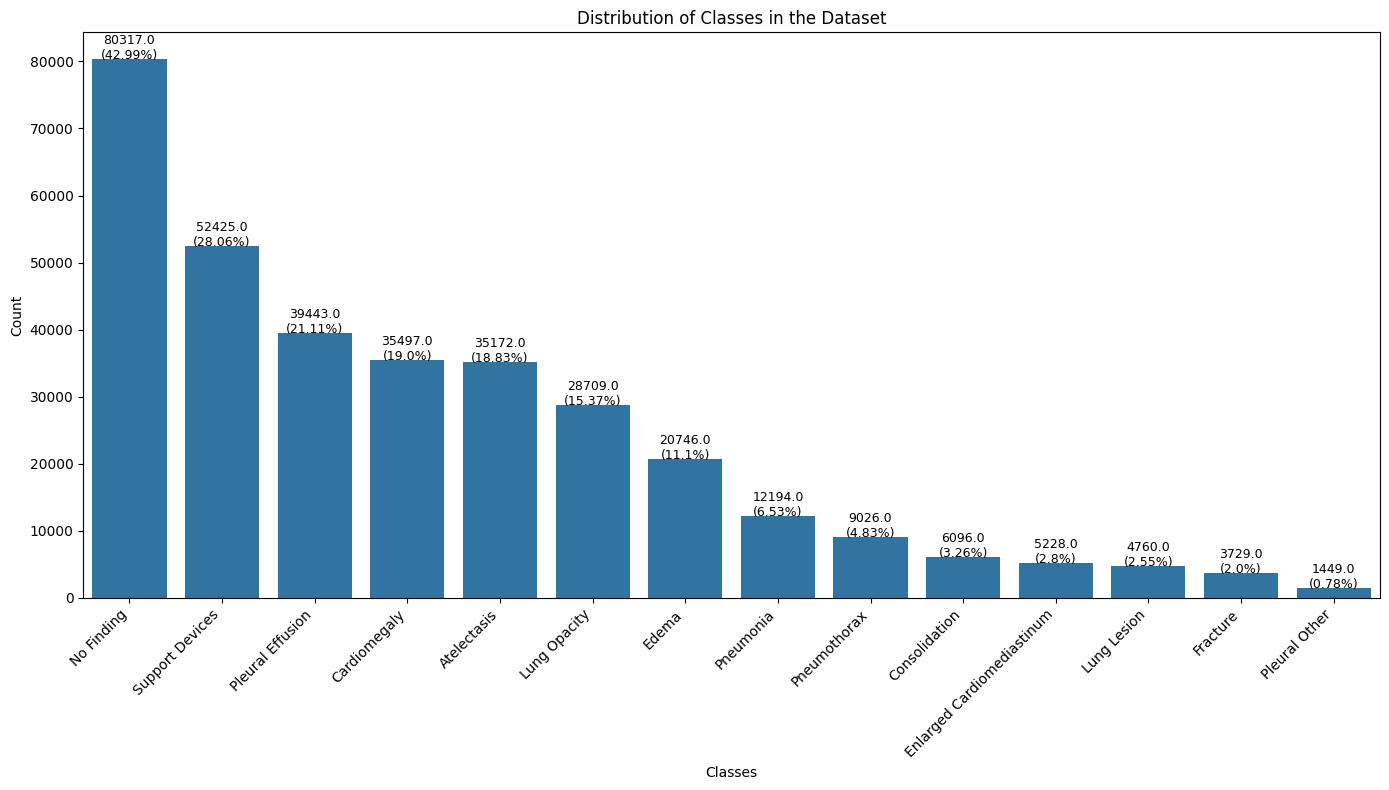


==== HANDLING DATA IMBALANCE ====
Images per class before balancing:
Pleural Other: 1449.0 images
Fracture: 3729.0 images
Lung Lesion: 4760.0 images
Enlarged Cardiomediastinum: 5228.0 images
Consolidation: 6096.0 images
Pneumothorax: 9026.0 images
Pneumonia: 12194.0 images
Edema: 20746.0 images
Lung Opacity: 28709.0 images
Atelectasis: 35172.0 images
Cardiomegaly: 35497.0 images
Pleural Effusion: 39443.0 images
Support Devices: 52425.0 images
No Finding: 80317.0 images

Minority class: Pleural Other with 1449.0 images
Target count for majority classes: 3449 images
Atelectasis: Reduced from 35172 to 3449 images
Cardiomegaly: Reduced from 35497 to 3449 images
Consolidation: Reduced from 6096 to 3449 images
Edema: Reduced from 20746 to 3449 images
Enlarged Cardiomediastinum: Reduced from 5228 to 3449 images
Fracture: Reduced from 3729 to 3449 images
Lung Lesion: Reduced from 4760 to 3449 images
Lung Opacity: Reduced from 28709 to 3449 images
No Finding: Reduced from 80317 to 3449 images


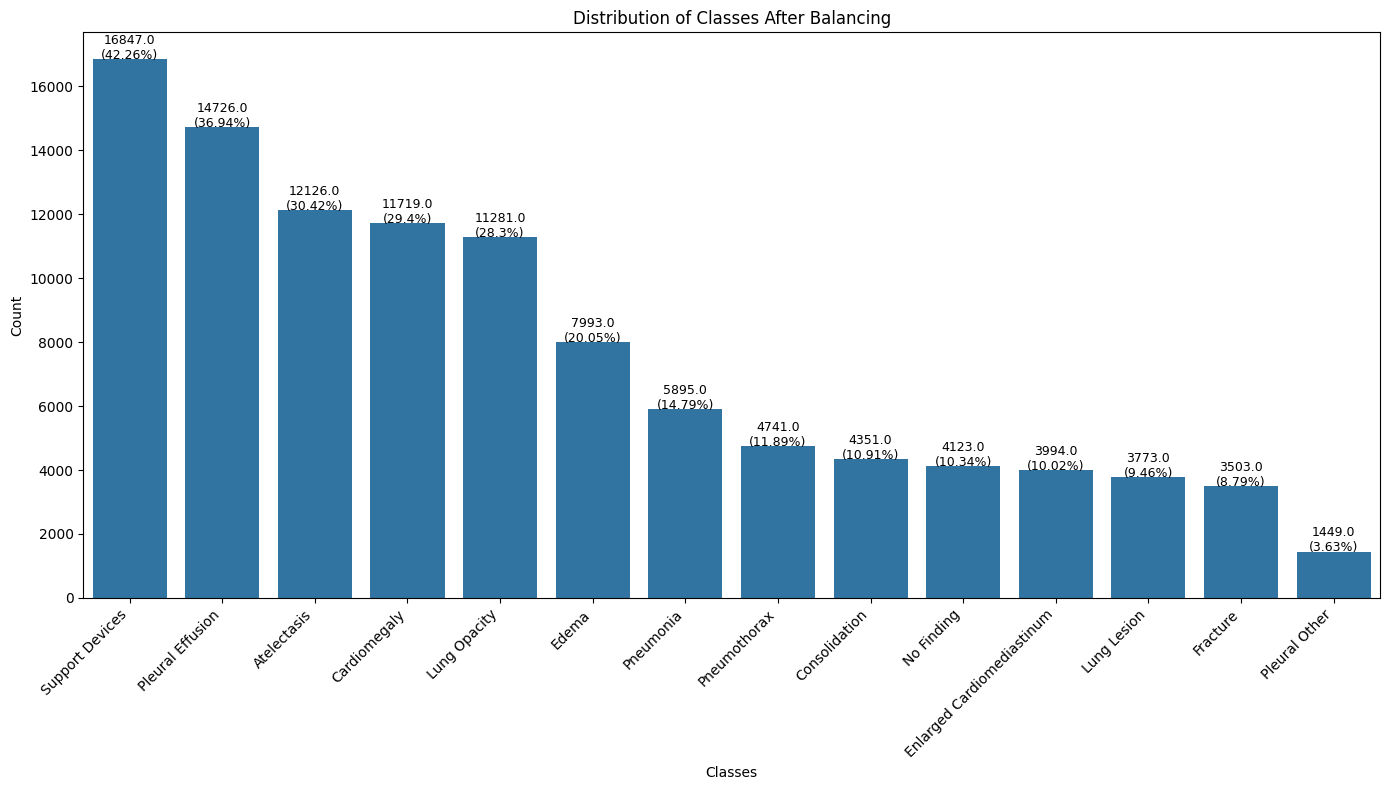

Label correlation plot saved to: /content/drive/MyDrive/ML Projects/chest_xray_classf/processed_data/visualizations/label_correlation.png


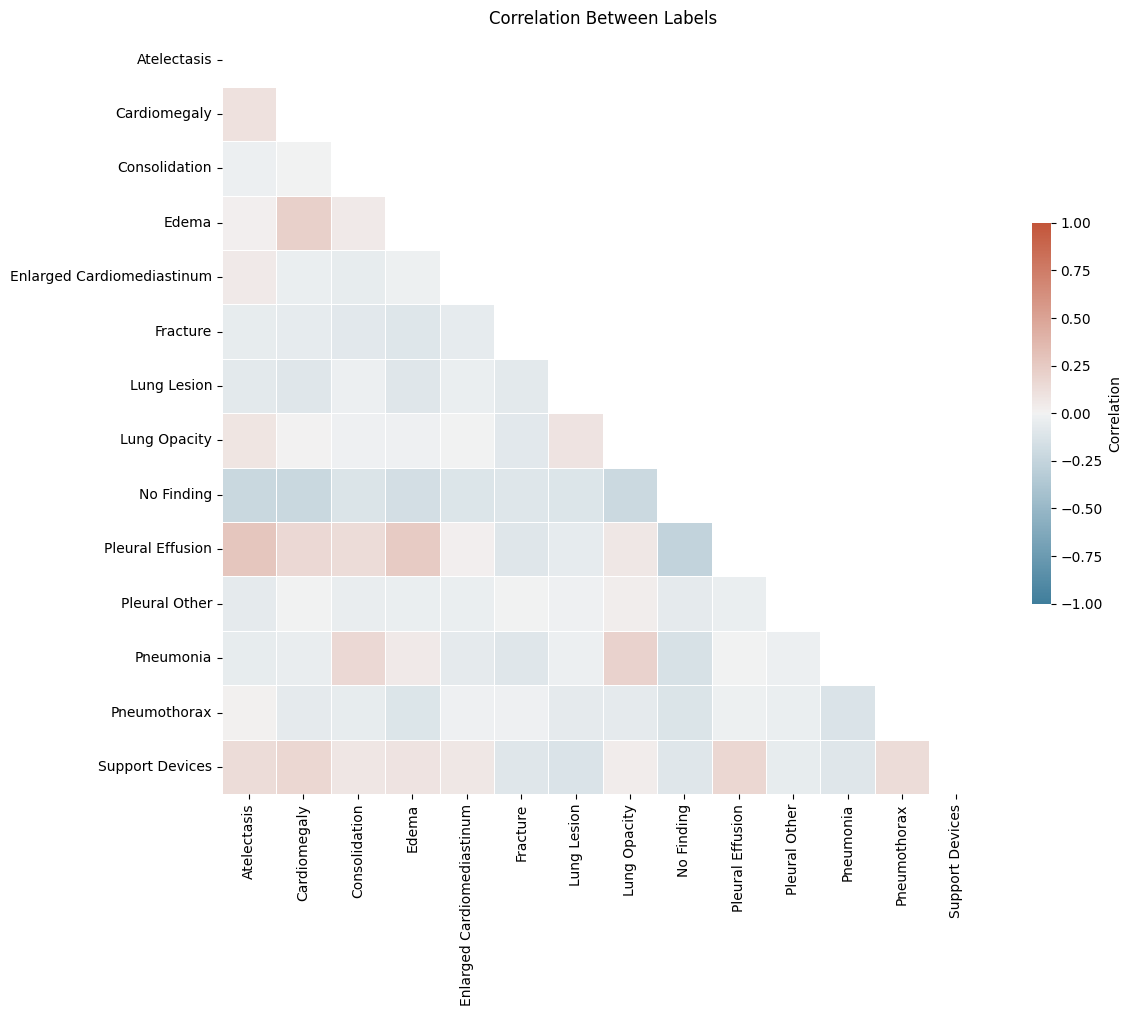

Sample images plot saved to: /content/drive/MyDrive/ML Projects/chest_xray_classf/processed_data/visualizations/sample_images.png


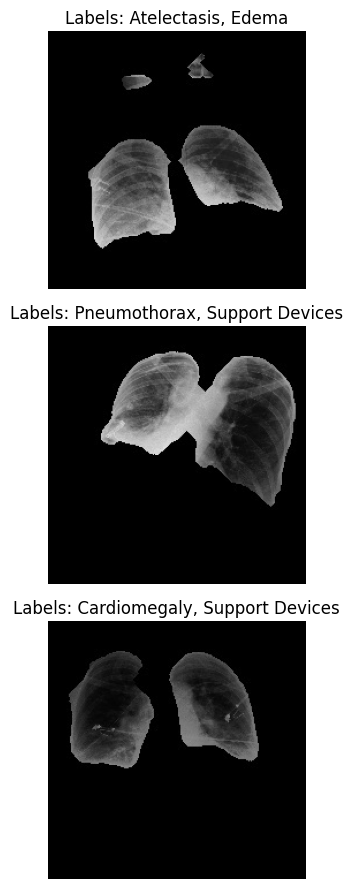


==== SPLITTING DATASET ====
Splitting dataset into train and test sets (test_size=0.2)
skmultilearn not found, using regular train_test_split
Split completed. Train: 31892, Test: 7974

Label distribution (proportion of positive samples):
Atelectasis: Train 30.33% | Test 30.75% | Diff 0.42%
Cardiomegaly: Train 29.38% | Test 29.45% | Diff 0.06%
Consolidation: Train 11.01% | Test 10.53% | Diff 0.47%
Edema: Train 19.97% | Test 20.35% | Diff 0.38%
Enlarged Cardiomediastinum: Train 10.03% | Test 9.98% | Diff 0.05%
Fracture: Train 8.81% | Test 8.70% | Diff 0.10%
Lung Lesion: Train 9.49% | Test 9.34% | Diff 0.15%
Lung Opacity: Train 28.25% | Test 28.51% | Diff 0.26%
No Finding: Train 10.34% | Test 10.35% | Diff 0.00%
Pleural Effusion: Train 36.96% | Test 36.86% | Diff 0.10%
Pleural Other: Train 3.62% | Test 3.67% | Diff 0.05%
Pneumonia: Train 14.78% | Test 14.81% | Diff 0.03%
Pneumothorax: Train 11.96% | Test 11.63% | Diff 0.33%
Support Devices: Train 42.26% | Test 42.26% | Diff 0.00%

==== C

/usr/local/lib/python3.11/dist-packages/albumentations/core/validation.py:87: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)
<ipython-input-7-aec1fbd32b5b>:425: UserWarning: Argument(s) 'var_limit' are not valid for transform GaussNoise
  A.GaussNoise(p=1, var_limit=(10.0, 30.0)),
Processing train images: 100%|██████████| 31892/31892 [06:07<00:00, 86.75it/s]


Saved processed train dataset to /content/drive/MyDrive/ML Projects/chest_xray_classf/processed_data/train_processed.csv
Total samples in processed train dataset: 95676
Original samples: 31892
Augmented samples: 63784

==== PROCESSING TEST DATASET ====
Preprocessing test dataset with 7974 samples


Processing test images: 100%|██████████| 7974/7974 [00:05<00:00, 1362.10it/s]


Saved processed test dataset to /content/drive/MyDrive/ML Projects/chest_xray_classf/processed_data/test_processed.csv
Total samples in processed test dataset: 7974
Original samples: 7974
Augmented samples: 0

==== PREPROCESSING COMPLETE ====
Train dataset: 95676 samples (31892 original + 63784 augmented)
Test dataset: 7974 samples
Train dataset saved to: /content/drive/MyDrive/ML Projects/chest_xray_classf/processed_data/train_processed.csv
Test dataset saved to: /content/drive/MyDrive/ML Projects/chest_xray_classf/processed_data/test_processed.csv


In [7]:
import os
import pandas as pd
import numpy as np
import torch
import base64
from io import BytesIO
import cv2
from PIL import Image
from sklearn.model_selection import train_test_split
from tqdm import tqdm
import matplotlib.pyplot as plt
from pathlib import Path
import albumentations as A
from albumentations.pytorch import ToTensorV2
import torch.nn as nn
import random
import seaborn as sns


# Set seed for reproducibility
def set_seed(seed=42):
    """Set seed for reproducibility"""
    np.random.seed(seed)
    random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False
    os.environ['PYTHONHASHSEED'] = str(seed)
    print(f"Random seed set to {seed}")

def decode_image(encoded_string, target_size=(224, 224)):
    """
    Decode base64 string back to image

    Args:
        encoded_string (str): Base64 encoded image
        target_size (tuple): Size to resize the image to

    Returns:
        np.array: Decoded image as numpy array
    """
    if encoded_string is None or pd.isna(encoded_string):
        # Return black image if string is None
        return np.zeros((*target_size, 3), dtype=np.uint8)

    try:
        # Decode base64 string
        img_bytes = base64.b64decode(encoded_string)

        # Convert to numpy array using OpenCV
        nparr = np.frombuffer(img_bytes, np.uint8)
        img = cv2.imdecode(nparr, cv2.IMREAD_COLOR)

        # Convert BGR to RGB (OpenCV loads as BGR)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        # Resize if needed
        if img.shape[:2] != target_size:
            img = cv2.resize(img, target_size)

        return img
    except Exception as e:
        print(f"Error decoding image: {e}")
        # Return black image if decoding fails
        return np.zeros((*target_size, 3), dtype=np.uint8)

def load_dataset(csv_path, sample_size=None, verbose=True):
    """
    Load dataset from CSV

    Args:
        csv_path (str): Path to CSV with images and labels
        sample_size (int, optional): Number of samples to load for testing
        verbose (bool): Whether to print information

    Returns:
        pd.DataFrame: DataFrame with images and labels
    """
    if verbose:
        print(f"Loading dataset from: {csv_path}")

    # Use optimized loading for large files
    if sample_size is not None and sample_size > 0:
        # Load a sample of the data for testing
        df = pd.read_csv(csv_path, nrows=sample_size)
        if verbose:
            print(f"Loaded sample of {len(df)} records for testing")
    else:
        # Load full dataset
        df = pd.read_csv(csv_path)
        if verbose:
            print(f"Loaded {len(df)} records")

    # Check if image column exists
    if 'image' not in df.columns:
        raise ValueError("Image column not found in the CSV. Expected column name: 'image'")

    # Identify label columns (all except 'image')
    label_cols = [col for col in df.columns if col != 'image']
    if verbose:
        print(f"Found {len(label_cols)} label columns: {label_cols}")

    # Basic data validation
    if verbose:
        # Count NA values in the image column
        na_images = df['image'].isna().sum()
        if na_images > 0:
            print(f"Warning: {na_images} missing images found")

        # Check for empty label rows (all labels are 0)
        empty_labels = (df[label_cols].sum(axis=1) == 0).sum()
        if empty_labels > 0:
            print(f"Warning: {empty_labels} rows with no positive labels found")

    return df, label_cols

def handle_data_imbalance(df, label_cols, save_path=None):
    """
    Handle data imbalance by limiting majority classes

    Args:
        df (pd.DataFrame): DataFrame with images and labels
        label_cols (list): List of label column names
        save_path (str, optional): Path to save the balanced class distribution plot

    Returns:
        pd.DataFrame: Balanced DataFrame
    """
    print("\n==== HANDLING DATA IMBALANCE ====")

    # Get count of images per class
    class_counts = df[label_cols].sum().sort_values()

    # Print images per class before balancing
    print("Images per class before balancing:")
    for label, count in class_counts.items():
        print(f"{label}: {count} images")

    # Find the minority class (class with the least images)
    minority_label = class_counts.index[0]
    minority_count = class_counts[minority_label]

    # Calculate target count for majority classes (minority_count + 2000)
    target_count = int(minority_count + 2000)
    print(f"\nMinority class: {minority_label} with {minority_count} images")
    print(f"Target count for majority classes: {target_count} images")

    # Instead of concatenating dataframes, we'll track indices to keep
    # This preserves multi-label information
    indices_to_keep = set()

    # Process each class
    for label in label_cols:
        # Get indices of rows with this label
        class_indices = df[df[label] == 1].index.tolist()
        class_count = len(class_indices)

        if class_count <= target_count:
            # If class count is already below target, keep all images
            print(f"{label}: Keeping all {class_count} images (below target)")
            indices_to_keep.update(class_indices)
        else:
            # If class count is above target, sample randomly to target count
            sampled_indices = np.random.choice(class_indices, target_count, replace=False)
            print(f"{label}: Reduced from {class_count} to {len(sampled_indices)} images")
            indices_to_keep.update(sampled_indices)

    # Create the balanced dataframe using the collected indices
    balanced_df = df.loc[list(indices_to_keep)].reset_index(drop=True)
    print(f"\nFinal balanced dataset size: {len(balanced_df)} images")

    # Get count of images per class after balancing
    balanced_counts = balanced_df[label_cols].sum().sort_values()

    # Print images per class after balancing
    print("\nImages per class after balancing:")
    for label, count in balanced_counts.items():
        print(f"{label}: {count} images")

    # Visualize the balanced class distribution
    plt.figure(figsize=(14, 8))

    # Calculate positive counts and percentages
    positive_counts = balanced_df[label_cols].sum().sort_values(ascending=False)
    total = len(balanced_df)
    percentages = (positive_counts / total * 100).round(2)

    # Create bar chart
    ax = sns.barplot(x=positive_counts.index, y=positive_counts.values)

    # Add percentages on top of bars
    for i, (count, pct) in enumerate(zip(positive_counts.values, percentages)):
        ax.text(i, count + 5, f"{count}\n({pct}%)", ha='center', fontsize=9)

    # Add labels and title
    plt.xlabel('Classes')
    plt.ylabel('Count')
    plt.title('Distribution of Classes After Balancing')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()

    # Save if requested
    if save_path:
        plt.savefig(save_path)
        print(f"Balanced class distribution plot saved to: {save_path}")

    plt.show()

    return balanced_df

def visualize_class_distribution(df, label_cols, save_path=None):
    """
    Visualize class distribution in the dataset

    Args:
        df (pd.DataFrame): DataFrame with labels
        label_cols (list): List of label column names
        save_path (str, optional): Path to save the plot
    """
    plt.figure(figsize=(14, 8))

    # Calculate positive counts and percentages
    positive_counts = df[label_cols].sum().sort_values(ascending=False)
    total = len(df)
    percentages = (positive_counts / total * 100).round(2)

    # Create bar chart
    ax = sns.barplot(x=positive_counts.index, y=positive_counts.values)

    # Add percentages on top of bars
    for i, (count, pct) in enumerate(zip(positive_counts.values, percentages)):
        ax.text(i, count + 5, f"{count}\n({pct}%)", ha='center', fontsize=9)

    # Add labels and title
    plt.xlabel('Classes')
    plt.ylabel('Count')
    plt.title('Distribution of Classes in the Dataset')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()

    # Save if requested
    if save_path:
        plt.savefig(save_path)
        print(f"Class distribution plot saved to: {save_path}")

    plt.show()

def visualize_label_correlation(df, label_cols, save_path=None):
    """
    Visualize correlation matrix between labels

    Args:
        df (pd.DataFrame): DataFrame with labels
        label_cols (list): List of label column names
        save_path (str, optional): Path to save the plot
    """
    # Calculate correlation matrix
    corr = df[label_cols].corr()

    # Plot correlation matrix
    plt.figure(figsize=(12, 10))
    mask = np.triu(np.ones_like(corr, dtype=bool))
    cmap = sns.diverging_palette(230, 20, as_cmap=True)

    sns.heatmap(
        corr,
        mask=mask,
        cmap=cmap,
        vmax=1,
        vmin=-1,
        center=0,
        square=True,
        linewidths=.5,
        cbar_kws={"shrink": .5, "label": "Correlation"}
    )

    plt.title('Correlation Between Labels')
    plt.tight_layout()

    # Save if requested
    if save_path:
        plt.savefig(save_path)
        print(f"Label correlation plot saved to: {save_path}")

    plt.show()

def visualize_sample_images(df, label_cols, num_samples=5, save_path=None):
    """
    Visualize sample images with their labels

    Args:
        df (pd.DataFrame): DataFrame with images and labels
        label_cols (list): List of label column names
        num_samples (int): Number of samples to visualize
        save_path (str, optional): Path to save the plot
    """
    # Get random samples
    samples = df.sample(min(num_samples, len(df)))

    # Create a figure with subplots
    fig, axes = plt.subplots(num_samples, 1, figsize=(12, num_samples * 3))
    if num_samples == 1:
        axes = [axes]

    for i, (_, row) in enumerate(samples.iterrows()):
        # Decode image
        img = decode_image(row['image'])

        # Get positive labels
        pos_labels = [label for label in label_cols if row[label] == 1]
        label_text = ', '.join(pos_labels)

        # Display image
        axes[i].imshow(img)
        axes[i].set_title(f"Labels: {label_text}")
        axes[i].axis('off')

    plt.tight_layout()

    # Save if requested
    if save_path:
        plt.savefig(save_path)
        print(f"Sample images plot saved to: {save_path}")

    plt.show()

def train_test_split_with_stratification(df, label_cols, test_size=0.2, seed=42):
    """
    Split dataset into train and test sets with iterative stratification for multilabel data

    Args:
        df (pd.DataFrame): DataFrame with images and labels
        label_cols (list): List of label column names
        test_size (float): Proportion of data to use for test set
        seed (int): Random seed

    Returns:
        pd.DataFrame, pd.DataFrame: Train and test DataFrames
    """
    print(f"Splitting dataset into train and test sets (test_size={test_size})")

    try:
        # Try to use iterative stratification for multilabel data
        from skmultilearn.model_selection import iterative_train_test_split

        # Prepare data for iterative_train_test_split
        X = np.array(range(len(df))).reshape(-1, 1)
        y = df[label_cols].values

        # Split the data
        X_train, y_train, X_test, y_test = iterative_train_test_split(X, y, test_size=test_size)

        # Get the indices for train and test sets
        train_indices = X_train.ravel()
        test_indices = X_test.ravel()

        print(f"Using iterative stratification for multilabel data")
    except (ImportError, ModuleNotFoundError):
        # Fall back to regular train_test_split
        # This is not ideal for multilabel but will work if skmultilearn is not available
        print(f"skmultilearn not found, using regular train_test_split")

        # For regular split, we'll stratify on the most common label
        most_common_label = df[label_cols].sum().idxmax()

        # Split the data
        train_indices, test_indices = train_test_split(
            range(len(df)),
            test_size=test_size,
            random_state=seed,
            stratify=df[most_common_label] if len(df[most_common_label].unique()) > 1 else None
        )

    # Create train and test dataframes
    train_df = df.iloc[train_indices].reset_index(drop=True)
    test_df = df.iloc[test_indices].reset_index(drop=True)

    print(f"Split completed. Train: {len(train_df)}, Test: {len(test_df)}")

    # Verify label distribution in train and test sets
    train_dist = train_df[label_cols].mean()
    test_dist = test_df[label_cols].mean()

    # Print statistics
    print("\nLabel distribution (proportion of positive samples):")
    for label in label_cols:
        train_pct = train_df[label].mean() * 100
        test_pct = test_df[label].mean() * 100
        diff = abs(train_pct - test_pct)
        print(f"{label}: Train {train_pct:.2f}% | Test {test_pct:.2f}% | Diff {diff:.2f}%")

    return train_df, test_df

def get_augmentations(phase, img_size=224):
    """
    Get augmentation pipeline based on phase (train/test)

    Args:
        phase (str): 'train' or 'test'
        img_size (int): Image size for the model

    Returns:
        A.Compose: Augmentation pipeline
    """
    if phase == 'train':
        # Training augmentations with more variety
        return A.Compose([
            # Spatial augmentations
            A.RandomResizedCrop(size=(img_size, img_size), scale=(0.8, 1.0)),
            A.HorizontalFlip(p=0.5),
            A.RandomRotate90(p=0.2),  # X-rays can be viewed from different angles
            A.ShiftScaleRotate(p=0.2, shift_limit=0.0625, scale_limit=0.1, rotate_limit=15),

            # Color augmentations (minimal for medical images)
            A.OneOf([
                A.RandomBrightnessContrast(p=1, brightness_limit=0.1, contrast_limit=0.1),
                A.RandomGamma(p=1, gamma_limit=(90, 110)),
            ], p=0.3),

            # Noise augmentations
            A.OneOf([
                A.GaussNoise(p=1, var_limit=(10.0, 30.0)),
                A.MultiplicativeNoise(p=1, multiplier=(0.95, 1.05)),
            ], p=0.2),

            # Blur and sharpness
            A.OneOf([
                A.Blur(p=1, blur_limit=3),
                A.Sharpen(p=1, alpha=(0.1, 0.3), lightness=(0.8, 1.2)),
            ], p=0.2),

            # Normalization and conversion to tensor
            A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
            ToTensorV2(),
        ])
    else:
        # Test/validation augmentations - just resize and normalize
        return A.Compose([
            A.Resize(height=img_size, width=img_size),
            A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
            ToTensorV2(),
        ])

def preprocess_and_augment_dataset(df, label_cols, output_path, is_train=True, img_size=224, num_augmentations=0):
    """
    Preprocess and augment images in the dataset

    Args:
        df (pd.DataFrame): DataFrame with images and labels
        label_cols (list): List of label column names
        output_path (str): Path to save the processed CSV
        is_train (bool): Whether this is training data (for augmentations)
        img_size (int): Target image size
        num_augmentations (int): Number of augmented copies to create per image (train only)

    Returns:
        pd.DataFrame: Processed DataFrame
    """
    phase = 'train' if is_train else 'test'
    print(f"Preprocessing {phase} dataset with {len(df)} samples")

    # Get the augmentation pipeline
    aug_pipeline = get_augmentations(phase, img_size)

    # List to store rows of the new dataframe
    processed_data = []

    # Process each row
    for idx, row in tqdm(df.iterrows(), total=len(df), desc=f"Processing {phase} images"):
        # Decode the base64 image
        img = decode_image(row['image'], target_size=(img_size, img_size))

        if img is None or img.size == 0:
            print(f"Warning: Empty image at index {idx}, skipping")
            continue

        # Extract labels
        labels = {label: row[label] for label in label_cols}

        # Always add the original image
        processed_data.append({
            **labels,
            'original_idx': idx,
            'is_augmented': 0
        })

        # Add augmented versions if training and augmentations requested
        if is_train and num_augmentations > 0:
            for aug_idx in range(num_augmentations):
                # Apply augmentation
                augmented = aug_pipeline(image=img)['image']

                # Convert tensor back to numpy for visualization/inspection if needed
                aug_img_np = augmented.permute(1, 2, 0).numpy()

                # Normalize back to 0-255 range for visualization if needed
                aug_img_np = ((aug_img_np * [0.229, 0.224, 0.225]) + [0.485, 0.456, 0.406]) * 255
                aug_img_np = np.clip(aug_img_np, 0, 255).astype(np.uint8)

                # Add to processed data
                processed_data.append({
                    **labels,
                    'original_idx': idx,
                    'is_augmented': 1,
                    'aug_idx': aug_idx
                })

    # Create DataFrame
    processed_df = pd.DataFrame(processed_data)

    # Save to CSV
    processed_df.to_csv(output_path, index=False)
    print(f"Saved processed {phase} dataset to {output_path}")

    # Print summary
    total_augmented = processed_df['is_augmented'].sum()
    print(f"Total samples in processed {phase} dataset: {len(processed_df)}")
    print(f"Original samples: {len(processed_df) - total_augmented}")
    print(f"Augmented samples: {total_augmented}")

    return processed_df

if __name__ == "__main__":
    # Set seed for reproducibility
    set_seed(42)

    # Setup GPU if available
    has_gpu = setup_gpu()
    print(f"GPU available: {has_gpu}")

    output_dir = "/content/drive/MyDrive/ML Projects/chest_xray_classf/processed_data"
    os.makedirs(output_dir, exist_ok=True)

    # Define paths
    input_csv_path = "/content/drive/MyDrive/ML Projects/chest_xray_classf/processed_data/images_with_labels.csv"
    train_csv_path = os.path.join(output_dir, "train_processed.csv")
    test_csv_path = os.path.join(output_dir, "test_processed.csv")

    # Define visualization paths
    vis_dir = os.path.join(output_dir, "visualizations")
    os.makedirs(vis_dir, exist_ok=True)

    # Load dataset
    print("\n==== LOADING DATASET ====")
    # Uncomment next line for testing with a small sample:
    # sample_size = 1000  # Small sample for testing
    sample_size = None  # Set to None for full dataset
    df, label_cols = load_dataset(input_csv_path, sample_size=sample_size)

    # Visualize dataset before balancing
    print("\n==== VISUALIZING DATASET BEFORE BALANCING ====")
    visualize_class_distribution(
        df,
        label_cols,
        save_path=os.path.join(vis_dir, "class_distribution_before_balancing.png")
    )

    # Handle data imbalance
    balanced_df = handle_data_imbalance(
        df,
        label_cols,
        save_path=os.path.join(vis_dir, "class_distribution_after_balancing.png")
    )

    # Use the balanced dataset for the rest of the process
    df = balanced_df

    visualize_label_correlation(
        df,
        label_cols,
        save_path=os.path.join(vis_dir, "label_correlation.png")
    )

    visualize_sample_images(
        df,
        label_cols,
        num_samples=3,
        save_path=os.path.join(vis_dir, "sample_images.png")
    )

    # Split dataset
    print("\n==== SPLITTING DATASET ====")
    train_df, test_df = train_test_split_with_stratification(df, label_cols, test_size=0.2)

    # Configure preprocessing parameters
    print("\n==== CONFIGURING PREPROCESSING ====")

    # Model specific configurations
    resnet_config = {
        'img_size': 224,  # ResNet standard input size
        'num_augmentations': 2  # Number of augmented copies per image
    }

    vit_config = {
        'img_size': 224,  # ViT-B/16 standard input size
        'num_augmentations': 2  # Number of augmented copies per image
    }

    # Choose configuration based on your preferred model
    model_config = resnet_config  # or vit_config

    print(f"Using image size: {model_config['img_size']}px")
    print(f"Augmentations per image: {model_config['num_augmentations']}")

    # Process train dataset with augmentations
    print("\n==== PROCESSING TRAIN DATASET ====")
    train_processed = preprocess_and_augment_dataset(
        train_df,
        label_cols,
        train_csv_path,
        is_train=True,
        img_size=model_config['img_size'],
        num_augmentations=model_config['num_augmentations']
    )

    # Process test dataset without augmentations
    print("\n==== PROCESSING TEST DATASET ====")
    test_processed = preprocess_and_augment_dataset(
        test_df,
        label_cols,
        test_csv_path,
        is_train=False,
        img_size=model_config['img_size'],
        num_augmentations=0  # No augmentations for test data
    )

    # Final summary
    print("\n==== PREPROCESSING COMPLETE ====")
    print(f"Train dataset: {len(train_processed)} samples ({len(train_df)} original + {len(train_processed) - len(train_df)} augmented)")
    print(f"Test dataset: {len(test_processed)} samples")
    print(f"Train dataset saved to: {train_csv_path}")
    print(f"Test dataset saved to: {test_csv_path}")


# Model Training & Evaluation

In [1]:
import os
import torch
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from pathlib import Path
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, SequentialSampler, SubsetRandomSampler
from torchvision import models, transforms
import base64
import cv2
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import json
import multiprocessing
import random

# Set the start method for multiprocessing to 'spawn' to fix CUDA in fork issue
# This must be done at the very beginning before any other multiprocessing code
if __name__ == "__main__":
    try:
        multiprocessing.set_start_method('spawn')
    except RuntimeError:
        # Method is already set
        pass

# Set seed for reproducibility
def set_seed(seed=42):
    """Set seed for reproducibility"""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False
    os.environ['PYTHONHASHSEED'] = str(seed)
    print(f"Random seed set to {seed}")

# Add this function near the top of the file, after the set_seed function
def setup_gpu():
    """Setup GPU and return whether it's available"""
    if torch.cuda.is_available():
        # Set device
        torch.cuda.set_device(0)
        # Print GPU info
        print(f"Using GPU: {torch.cuda.get_device_name(0)}")
        return True
    else:
        print("No GPU available, using CPU")
        return False

# Function to decode base64 image
def decode_image(encoded_string, target_size=(224, 224)):
    """Decode base64 string back to image"""
    if encoded_string is None or pd.isna(encoded_string):
        return torch.zeros((3, *target_size), dtype=torch.float32)

    try:
        # Decode base64 string
        if isinstance(encoded_string, str):
            img_bytes = base64.b64decode(encoded_string)
        else:
            img_bytes = base64.b64decode(encoded_string.encode('utf-8'))

        # Convert to numpy array using OpenCV
        nparr = np.frombuffer(img_bytes, np.uint8)
        img = cv2.imdecode(nparr, cv2.IMREAD_COLOR)

        # Convert BGR to RGB (OpenCV loads as BGR)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        # Resize if needed
        if img.shape[:2] != target_size:
            img = cv2.resize(img, target_size)

        # Convert to tensor and normalize
        transform = transforms.Compose([
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
        ])

        img_tensor = transform(img)
        return img_tensor
    except Exception as e:
        print(f"Error decoding image: {e}")
        return torch.zeros((3, *target_size), dtype=torch.float32)

# Custom dataset class for multilabel images
class ChestXrayDataset(Dataset):
    def __init__(self, csv_path, label_cols, transform=None, sample_size=None, is_test=False, decode_on_the_fly=True):
        """
        Args:
            csv_path (str): Path to the CSV file with image paths and labels
            label_cols (list): List of label column names
            transform (callable, optional): Optional transform to be applied to the image
            sample_size (int, optional): Number of samples to use (for debugging/testing)
            is_test (bool): Whether this is a test dataset
            decode_on_the_fly (bool): Whether to decode images on the fly or preload
        """
        # Load csv file
        if sample_size:
            self.data = pd.read_csv(csv_path, nrows=sample_size)
        else:
            self.data = pd.read_csv(csv_path)

        self.label_cols = label_cols
        self.transform = transform
        self.is_test = is_test

        # Check if 'image' column exists in the data
        if 'image' not in self.data.columns:
            print("Warning: 'image' column not found in the CSV. Make sure your data includes the base64 encoded images.")
            # If you have a separate column with image paths, you could load from there instead

        # If is_test is True, filter out augmented data
        if self.is_test and 'is_augmented' in self.data.columns:
            # In test set we don't want augmented images
            self.data = self.data[self.data['is_augmented'] == 0].reset_index(drop=True)

        # Whether to decode images on the fly (memory efficient) or preload (faster)
        self.decode_on_the_fly = decode_on_the_fly

        # If not decoding on the fly, preload all images
        if not self.decode_on_the_fly:
            print("Preloading images... (this may take a while)")
            self.images = [decode_image(row.get('image', None)) for _, row in tqdm(self.data.iterrows(), total=len(self.data))]

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        row = self.data.iloc[idx]

        # Get labels - Convert to NumPy first to avoid CUDA issues with tensor creation
        # Ensure we create CPU tensors only
        label_values = row[self.label_cols].values.astype(np.float32)
        labels = torch.tensor(label_values, dtype=torch.float32)

        # Get image
        if self.decode_on_the_fly:
            image = decode_image(row.get('image', None))
        else:
            image = self.images[idx]

        # Apply transformations
        if self.transform:
            image = self.transform(image)

        return image, labels, idx

# Create ResNet50 model for multilabel classification
def create_model(num_classes, pretrained=True, freeze_backbone=False):
    """Create a ResNet50 model for multilabel classification"""
    model = models.resnet50(weights='IMAGENET1K_V2' if pretrained else None)

    # Freeze backbone if requested
    if freeze_backbone:
        for param in model.parameters():
            param.requires_grad = False

    # Replace the last fully connected layer for multilabel classification
    in_features = model.fc.in_features
    model.fc = nn.Sequential(
        nn.Dropout(0.3),  # Dropout for regularization
        nn.Linear(in_features, num_classes)
        # No sigmoid here since we're using BCEWithLogitsLoss
    )

    return model

# Custom RandomSampler that doesn't use a generator
class SafeRandomSampler(SubsetRandomSampler):
    """Random sampler that doesn't use a CUDA generator"""
    def __iter__(self):
        # Use numpy for shuffling instead of torch.randperm to avoid CUDA generator issues
        indices = list(range(len(self.indices)))
        np.random.shuffle(indices)
        return iter(self.indices[i] for i in indices)

# Function to safely move tensors to device
def to_device(data, device):
    """Move tensor(s) to chosen device"""
    if isinstance(data, (list, tuple)):
        return [to_device(x, device) for x in data]
    return data.to(device, non_blocking=True)

# Custom DataLoader to handle device transfers
class DeviceDataLoader:
    def __init__(self, dataloader, device):
        self.dataloader = dataloader
        self.device = device
        self.dataset = dataloader.dataset
        self.batch_size = dataloader.batch_size

    def __iter__(self):
        for batch in self.dataloader:
            yield to_device(batch, self.device)

    def __len__(self):
        return len(self.dataloader)

# Training loop for one epoch with simpler, safer implementation
def train_one_epoch(model, dataloader, criterion, optimizer, device):
    """Train model for one epoch with safer implementation"""
    model.train()
    running_loss = 0.0
    all_labels = []
    all_preds = []
    total_samples = 0

    # Process each batch
    for images, labels, _ in tqdm(dataloader, desc="Training"):
        # Data should already be on device from DeviceDataLoader
        batch_size = images.size(0)
        total_samples += batch_size

        # Zero the parameter gradients
        optimizer.zero_grad()

        # Forward + backward + optimize
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        # Statistics
        running_loss += loss.item() * batch_size

        # Apply sigmoid to get probabilities
        probs = torch.sigmoid(outputs)

        # Convert outputs to binary predictions (threshold = 0.5)
        preds = (probs > 0.5).float().cpu().detach().numpy()
        all_preds.append(preds)
        all_labels.append(labels.cpu().detach().numpy())

    # Concatenate batch results
    all_preds = np.concatenate(all_preds)
    all_labels = np.concatenate(all_labels)

    # Calculate metrics
    accuracy = accuracy_score(all_labels.flatten(), all_preds.flatten())
    precision = precision_score(all_labels.flatten(), all_preds.flatten(), zero_division=0)
    recall = recall_score(all_labels.flatten(), all_preds.flatten(), zero_division=0)
    f1 = f1_score(all_labels.flatten(), all_preds.flatten(), zero_division=0)

    epoch_loss = running_loss / total_samples

    return epoch_loss, accuracy, precision, recall, f1

# Evaluation function
def evaluate(model, dataloader, criterion, device, label_cols):
    """Evaluate model on validation/test data"""
    model.eval()
    running_loss = 0.0
    all_labels = []
    all_preds = []
    all_outputs = []
    total_samples = 0

    with torch.no_grad():
        for images, labels, _ in tqdm(dataloader, desc="Evaluating"):
            # Data should already be on device from DeviceDataLoader
            batch_size = images.size(0)
            total_samples += batch_size

            # Forward
            outputs = model(images)
            loss = criterion(outputs, labels)

            # Statistics
            running_loss += loss.item() * batch_size

            # Apply sigmoid to get probabilities
            probs = torch.sigmoid(outputs)

            # Store predictions and labels
            preds = (probs > 0.5).float().cpu().numpy()
            outputs_np = probs.cpu().numpy()  # Store probabilities
            all_preds.append(preds)
            all_labels.append(labels.cpu().numpy())
            all_outputs.append(outputs_np)

    # Concatenate batch results
    all_preds = np.concatenate(all_preds)
    all_labels = np.concatenate(all_labels)
    all_outputs = np.concatenate(all_outputs)

    # Calculate overall metrics
    accuracy = accuracy_score(all_labels.flatten(), all_preds.flatten())
    precision = precision_score(all_labels.flatten(), all_preds.flatten(), zero_division=0)
    recall = recall_score(all_labels.flatten(), all_preds.flatten(), zero_division=0)
    f1 = f1_score(all_labels.flatten(), all_preds.flatten(), zero_division=0)

    # Calculate per-class metrics
    class_metrics = {}
    for i, label in enumerate(label_cols):
        class_preds = all_preds[:, i]
        class_labels = all_labels[:, i]

        class_acc = accuracy_score(class_labels, class_preds)
        class_prec = precision_score(class_labels, class_preds, zero_division=0)
        class_rec = recall_score(class_labels, class_preds, zero_division=0)
        class_f1 = f1_score(class_labels, class_preds, zero_division=0)

        class_metrics[label] = {
            'accuracy': float(class_acc),
            'precision': float(class_prec),
            'recall': float(class_rec),
            'f1_score': float(class_f1)
        }

    # Calculate confusion matrices for each class
    cms = {}
    for i, label in enumerate(label_cols):
        cms[label] = confusion_matrix(all_labels[:, i], all_preds[:, i])

    epoch_loss = running_loss / total_samples

    result = {
        'loss': epoch_loss,
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1_score': f1,
        'class_metrics': class_metrics,
        'confusion_matrices': cms,
        'predictions': all_preds,
        'ground_truth': all_labels,
        'outputs': all_outputs
    }

    return result

def plot_confusion_matrices(cms, label_cols, save_dir):
    """Plot confusion matrices for each class"""
    os.makedirs(save_dir, exist_ok=True)

    for i, label in enumerate(label_cols):
        plt.figure(figsize=(8, 6))
        cm = cms[label]

        # Calculate normalized confusion matrix
        cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
        cm_norm = np.nan_to_num(cm_norm)  # Replace NaN with 0

        # Plot confusion matrix
        sns.heatmap(
            cm_norm,
            annot=cm,  # Show raw counts in cells
            fmt='d',
            cmap='Blues',
            xticklabels=['Negative', 'Positive'],
            yticklabels=['Negative', 'Positive']
        )
        plt.title(f'Confusion Matrix: {label}')
        plt.xlabel('Predicted')
        plt.ylabel('Actual')
        plt.tight_layout()

        # Save figure
        plt.savefig(os.path.join(save_dir, f'confusion_matrix_{label}.png'))
        plt.close()

def plot_metrics_history(train_losses, val_losses, train_metrics, val_metrics, save_dir):
    """Plot training and validation metrics history"""
    os.makedirs(save_dir, exist_ok=True)

    # Plot loss
    plt.figure(figsize=(10, 6))
    plt.plot(train_losses, label='Train Loss')
    plt.plot(val_losses, label='Validation Loss')
    plt.title('Loss over Training')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)
    plt.savefig(os.path.join(save_dir, 'loss_history.png'))
    plt.close()

    # Plot accuracy
    plt.figure(figsize=(10, 6))
    plt.plot([m['accuracy'] for m in train_metrics], label='Train Accuracy')
    plt.plot([m['accuracy'] for m in val_metrics], label='Validation Accuracy')
    plt.title('Accuracy over Training')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True)
    plt.savefig(os.path.join(save_dir, 'accuracy_history.png'))
    plt.close()

    # Plot F1 Score
    plt.figure(figsize=(10, 6))
    plt.plot([m['f1_score'] for m in train_metrics], label='Train F1 Score')
    plt.plot([m['f1_score'] for m in val_metrics], label='Validation F1 Score')
    plt.title('F1 Score over Training')
    plt.xlabel('Epochs')
    plt.ylabel('F1 Score')
    plt.legend()
    plt.grid(True)
    plt.savefig(os.path.join(save_dir, 'f1_history.png'))
    plt.close()

def save_metrics_to_json(metrics, filename):
    """Save metrics to JSON file"""
    # Convert numpy values to Python native types for JSON serialization
    def convert_to_serializable(obj):
        if isinstance(obj, np.ndarray):
            return obj.tolist()
        elif isinstance(obj, np.integer):
            return int(obj)
        elif isinstance(obj, np.floating):
            return float(obj)
        elif isinstance(obj, dict):
            return {key: convert_to_serializable(value) for key, value in obj.items()}
        elif isinstance(obj, list):
            return [convert_to_serializable(item) for item in obj]
        else:
            return obj

    # Prepare serializable metrics (exclude large arrays)
    serializable_metrics = {
        'loss': metrics['loss'],
        'accuracy': metrics['accuracy'],
        'precision': metrics['precision'],
        'recall': metrics['recall'],
        'f1_score': metrics['f1_score'],
        'class_metrics': metrics['class_metrics']
    }

    # Convert to serializable format
    serializable_metrics = convert_to_serializable(serializable_metrics)

    # Save to JSON
    with open(filename, 'w') as f:
        json.dump(serializable_metrics, f, indent=4)

    print(f"Metrics saved to {filename}")

# Replace the standard BCE loss with a weighted version
def get_weighted_loss(label_cols, train_dataset, device):
    """Create a weighted BCE loss to handle class imbalance"""
    # Calculate class weights based on inverse frequency
    pos_weights = []
    for label in label_cols:
        # Count positive samples for this class
        pos_count = train_dataset.data[label].sum()
        neg_count = len(train_dataset.data) - pos_count

        # Calculate weight (higher weight for minority class)
        if pos_count > 0:
            weight = neg_count / pos_count
        else:
            weight = 1.0

        pos_weights.append(weight)

    # Create tensor of weights and move to the correct device
    pos_weights = torch.tensor(pos_weights, dtype=torch.float32).to(device)

    # Print weights for debugging
    print("Class weights for loss function:")
    for label, weight in zip(label_cols, pos_weights.cpu().numpy()):
        print(f"{label}: {weight:.2f}")

    # Return weighted BCE loss
    return nn.BCEWithLogitsLoss(pos_weight=pos_weights)

# Add this after creating the datasets but before training
def verify_dataset(dataset, num_samples=5):
    """Verify dataset by displaying some samples"""
    print(f"\nVerifying dataset with {len(dataset)} samples")

    # Check if 'image' column exists in the dataset
    if hasattr(dataset, 'data') and 'image' in dataset.data.columns:
        # Check if images are actually present (not None or empty)
        num_empty = dataset.data['image'].isna().sum()
        print(f"Number of empty images: {num_empty} out of {len(dataset)}")

        # Check a few random samples
        indices = np.random.choice(len(dataset), min(num_samples, len(dataset)), replace=False)
        for i, idx in enumerate(indices):
            img, labels, _ = dataset[idx]
            if isinstance(img, torch.Tensor):
                # Check if image tensor contains all zeros or NaNs
                if torch.all(img == 0) or torch.isnan(img).any():
                    print(f"Sample {i+1}: Empty or invalid image tensor")
                else:
                    print(f"Sample {i+1}: Valid image tensor with shape {img.shape}")
            else:
                print(f"Sample {i+1}: Image is not a tensor, type: {type(img)}")

            # Print positive labels
            pos_labels = [dataset.label_cols[j] for j in range(len(labels)) if labels[j] == 1]
            print(f"  Positive labels: {pos_labels}")
    else:
        #print("Warning: 'image' column not found in dataset")
        pass

def main():
    # Set seed for reproducibility
    set_seed(42)

    # Setup GPU
    has_gpu = setup_gpu()
    device = torch.device("cuda" if has_gpu else "cpu")
    print(f"Using device: {device}")

    base_dir = "/content/drive/MyDrive/ML Projects/chest_xray_classf"
    data_dir = os.path.join(base_dir, "processed_data")
    output_dir = os.path.join(base_dir, "model_outputs", "resnet50")
    os.makedirs(output_dir, exist_ok=True)

    # Set to small sample size for debugging or None for full dataset
    # sample_size = 1000  # Uncomment for debugging
    sample_size = None

    # Load data
    print("Loading data...")
    train_csv = os.path.join(data_dir, "train_processed.csv")
    test_csv = os.path.join(data_dir, "test_processed.csv")

    # Load a small portion to get label columns
    df_sample = pd.read_csv(train_csv, nrows=100)
    label_cols = [col for col in df_sample.columns if col not in ['image', 'original_idx', 'is_augmented', 'aug_idx']]
    print(f"Found {len(label_cols)} label columns")

    # Create datasets
    print("Creating datasets...")
    train_dataset = ChestXrayDataset(
        train_csv,
        label_cols,
        sample_size=sample_size,
        is_test=False
    )

    val_dataset = ChestXrayDataset(
        test_csv,
        label_cols,
        sample_size=sample_size,
        is_test=True
    )

    print(f"Train dataset size: {len(train_dataset)}")
    print(f"Validation dataset size: {len(val_dataset)}")

    # Call the verification function
    print("\nVerifying training dataset:")
    verify_dataset(train_dataset)
    print("\nVerifying validation dataset:")
    verify_dataset(val_dataset)

    # Create dataloaders without any possible CUDA generator issues
    batch_size = 32

    # Create a list of indices for the training dataset - using numpy to avoid torch.randperm
    train_indices = list(range(len(train_dataset)))
    np.random.shuffle(train_indices)  # CPU-based shuffle

    # Use a custom sampler that doesn't depend on the torch generator
    train_sampler = SubsetRandomSampler(train_indices)

    # Create DataLoaders with NO pin_memory, NO workers and CPU-only operations
    train_loader = DataLoader(
        train_dataset,
        batch_size=batch_size,
        sampler=train_sampler,  # Use our safe sampler
        num_workers=0,  # No workers
        pin_memory=False,  # No pin memory
        generator=None  # No generator
    )

    val_loader = DataLoader(
        val_dataset,
        batch_size=batch_size,
        shuffle=False,  # No need to shuffle validation
        num_workers=0,  # No workers
        pin_memory=False  # No pin memory
    )

    # Wrap DataLoaders with DeviceDataLoader to handle device transfers
    train_loader = DeviceDataLoader(train_loader, device)
    val_loader = DeviceDataLoader(val_loader, device)

    # Create model
    num_classes = len(label_cols)
    model = create_model(num_classes, pretrained=True, freeze_backbone=False)
    model = model.to(device)
    print(f"Created ResNet-50 model with {num_classes} output classes")

    # Print GPU usage before training
    if has_gpu:
        print("\nGPU Memory Usage Before Training:")
        print(f"Allocated: {torch.cuda.memory_allocated() / 1024**2:.2f} MB")
        print(f"Cached: {torch.cuda.memory_reserved() / 1024**2:.2f} MB")

    # Define loss function and optimizer with weighted loss
    criterion = get_weighted_loss(label_cols, train_dataset, device)
    optimizer = optim.Adam(model.parameters(), lr=0.0003)  # Increased learning rate
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', factor=0.5, patience=2, verbose=True
    )

    # Training parameters
    num_epochs = 15  # More epochs for better training

    # Lists to store metrics
    train_losses = []
    val_losses = []
    train_metrics_history = []
    val_metrics_history = []

    # Make sure all output directories exist
    os.makedirs(output_dir, exist_ok=True)
    models_dir = os.path.join(output_dir, 'models')
    os.makedirs(models_dir, exist_ok=True)
    plots_dir = os.path.join(output_dir, 'plots')
    os.makedirs(plots_dir, exist_ok=True)
    cm_dir = os.path.join(output_dir, 'confusion_matrices')
    os.makedirs(cm_dir, exist_ok=True)

    # Best model tracking
    best_val_f1 = 0.0
    best_epoch = -1  # -1 indicates no best model saved yet
    best_model_path = os.path.join(models_dir, 'best_model.pth')
    best_weights_path = os.path.join(models_dir, 'best_model_weights.pth')

    # Training loop
    print(f"Starting training for {num_epochs} epochs...")
    for epoch in range(num_epochs):
        print(f"\nEpoch {epoch+1}/{num_epochs}")

        # Reshuffle training data indices between epochs using numpy (CPU-based)
        if epoch > 0:  # Not needed for the first epoch since we already shuffled
            # Re-create train loader with new shuffled indices to ensure proper shuffling
            train_indices = list(range(len(train_dataset)))
            np.random.shuffle(train_indices)  # CPU-based shuffle

            train_sampler = SubsetRandomSampler(train_indices)
            train_loader_raw = DataLoader(
                train_dataset,
                batch_size=batch_size,
                sampler=train_sampler,
                num_workers=0,
                pin_memory=False,
                generator=None
            )
            train_loader = DeviceDataLoader(train_loader_raw, device)

        # Train
        train_loss, train_acc, train_prec, train_rec, train_f1 = train_one_epoch(
            model, train_loader, criterion, optimizer, device
        )

        train_losses.append(train_loss)
        train_metrics_history.append({
            'accuracy': train_acc,
            'precision': train_prec,
            'recall': train_rec,
            'f1_score': train_f1
        })

        # Validate
        val_metrics = evaluate(model, val_loader, criterion, device, label_cols)
        val_loss = val_metrics['loss']
        val_acc = val_metrics['accuracy']
        val_prec = val_metrics['precision']
        val_rec = val_metrics['recall']
        val_f1 = val_metrics['f1_score']

        val_losses.append(val_loss)
        val_metrics_history.append({
            'accuracy': val_acc,
            'precision': val_prec,
            'recall': val_rec,
            'f1_score': val_f1
        })

        # Update learning rate
        scheduler.step(val_loss)

        # Print metrics
        print(f"Train Loss: {train_loss:.4f}, Acc: {train_acc:.4f}, F1: {train_f1:.4f}")
        print(f"Val Loss: {val_loss:.4f}, Acc: {val_acc:.4f}, F1: {val_f1:.4f}")

        # Print GPU memory usage
        if has_gpu:
            print(f"GPU Memory: {torch.cuda.memory_allocated() / 1024**2:.2f} MB allocated")

        # Save best model
        if val_f1 > best_val_f1:
            best_val_f1 = val_f1
            best_epoch = epoch

            # Save model with full checkpoint
            print(f"Saving new best model with F1: {val_f1:.4f}")
            try:
                torch.save({
                    'epoch': epoch,
                    'model_state_dict': model.state_dict(),
                    'optimizer_state_dict': optimizer.state_dict(),
                    'val_f1': val_f1,
                    'val_loss': val_loss,
                    'label_cols': label_cols,  # Save label columns for inference
                }, best_model_path)

                # Also save a standalone model (just the weights) for easier loading
                torch.save(model.state_dict(), best_weights_path)

                print(f"Model successfully saved to {best_model_path}")
            except Exception as e:
                print(f"Error saving model: {e}")

        # Save checkpoint every epoch to allow for resuming training
        checkpoint_path = os.path.join(models_dir, f'checkpoint_epoch_{epoch+1}.pth')
        try:
            torch.save({
                'epoch': epoch,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'scheduler_state_dict': scheduler.state_dict(),
                'train_losses': train_losses,
                'val_losses': val_losses,
                'train_metrics': train_metrics_history,
                'val_metrics': val_metrics_history,
                'best_val_f1': best_val_f1,
                'best_epoch': best_epoch,
                'label_cols': label_cols,
            }, checkpoint_path)
        except Exception as e:
            print(f"Error saving checkpoint: {e}")

    print(f"\nTraining completed. Best model from epoch {best_epoch+1} with F1: {best_val_f1:.4f}")

    # Plot training history
    try:
        plot_metrics_history(
            train_losses,
            val_losses,
            train_metrics_history,
            val_metrics_history,
            plots_dir
        )
        print(f"Training plots saved to {plots_dir}")
    except Exception as e:
        print(f"Error creating plots: {e}")

    # Use current model if no best model was saved or best model can't be loaded
    final_model = model

    # Try to load best model for final evaluation
    if best_epoch >= 0:
        print(f"Attempting to load best model from epoch {best_epoch+1}...")
        try:
            if os.path.exists(best_model_path):
                checkpoint = torch.load(best_model_path)
                model.load_state_dict(checkpoint['model_state_dict'])
                final_model = model
                print(f"Successfully loaded best model from epoch {best_epoch+1}")
            else:
                print(f"Best model file not found at {best_model_path}. Using current model for evaluation.")
                # We'll use the current model which is already in 'final_model'
        except Exception as e:
            print(f"Error loading best model: {e}. Using current model for evaluation.")
            # We'll use the current model which is already in 'final_model'
    else:
        print("No best model was saved during training. Using current model for evaluation.")

    # Perform final evaluation on test set
    print("\nPerforming final evaluation on test set...")
    test_metrics = evaluate(final_model, val_loader, criterion, device, label_cols)

    # Print overall metrics
    print("\nFinal Test Metrics:")
    print(f"Loss: {test_metrics['loss']:.4f}")
    print(f"Accuracy: {test_metrics['accuracy']:.4f}")
    print(f"Precision: {test_metrics['precision']:.4f}")
    print(f"Recall: {test_metrics['recall']:.4f}")
    print(f"F1 Score: {test_metrics['f1_score']:.4f}")

    # Print per-class metrics
    print("\nPer-Class Metrics:")
    for label, metrics in test_metrics['class_metrics'].items():
        print(f"\n{label}:")
        print(f"  Accuracy: {metrics['accuracy']:.4f}")
        print(f"  Precision: {metrics['precision']:.4f}")
        print(f"  Recall: {metrics['recall']:.4f}")
        print(f"  F1 Score: {metrics['f1_score']:.4f}")

    # Plot confusion matrices
    try:
        plot_confusion_matrices(
            test_metrics['confusion_matrices'],
            label_cols,
            cm_dir
        )
        print(f"Confusion matrices saved to {cm_dir}")
    except Exception as e:
        print(f"Error creating confusion matrices: {e}")

    # Save metrics to json
    try:
        metrics_path = os.path.join(output_dir, 'test_metrics.json')
        save_metrics_to_json(test_metrics, metrics_path)
        print(f"Test metrics saved to {metrics_path}")
    except Exception as e:
        print(f"Error saving metrics: {e}")

    print("\nAll results saved to:", output_dir)

    # Save final model
    final_model_path = os.path.join(models_dir, 'final_model.pth')
    try:
        torch.save({
            'model_state_dict': final_model.state_dict(),
            'label_cols': label_cols,
        }, final_model_path)
        print(f"Final model saved to {final_model_path}")
    except Exception as e:
        print(f"Error saving final model: {e}")

if __name__ == "__main__":
    main()


Random seed set to 42
Using GPU: NVIDIA L4
Using device: cuda
Loading data...
Found 14 label columns
Creating datasets...
Train dataset size: 95676
Validation dataset size: 7974

Verifying training dataset:

Verifying dataset with 95676 samples

Verifying validation dataset:

Verifying dataset with 7974 samples


Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth
100%|██████████| 97.8M/97.8M [00:00<00:00, 172MB/s]
/usr/local/lib/python3.11/dist-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


Created ResNet-50 model with 14 output classes

GPU Memory Usage Before Training:
Allocated: 90.02 MB
Cached: 118.00 MB
Class weights for loss function:
Atelectasis: 2.30
Cardiomegaly: 2.40
Consolidation: 8.08
Edema: 4.01
Enlarged Cardiomediastinum: 8.97
Fracture: 10.35
Lung Lesion: 9.53
Lung Opacity: 2.54
No Finding: 8.67
Pleural Effusion: 1.71
Pleural Other: 26.59
Pneumonia: 5.77
Pneumothorax: 7.36
Support Devices: 1.37
Starting training for 15 epochs...

Epoch 1/15


Evaluating: 100%|██████████| 250/250 [00:15<00:00, 15.76it/s]


Train Loss: 1.1222, Acc: 0.4920, F1: 0.2757
Val Loss: 1.6000, Acc: 0.6348, F1: 0.3336
GPU Memory: 389.83 MB allocated
Saving new best model with F1: 0.3336
Model successfully saved to /content/drive/MyDrive/ML Projects/chest_xray_classf/model_outputs/resnet50/models/best_model.pth

Epoch 2/15


...

Train Loss: 1.1217, Acc: 0.3557, F1: 0.2965
Val Loss: 16.4565, Acc: 0.5704, F1: 0.3782
GPU Memory: 389.83 MB allocated

Epoch 15/15


Evaluating: 100%|██████████| 250/250 [00:15<00:00, 15.69it/s]


Train Loss: 1.1217, Acc: 0.4137, F1: 0.2870
Val Loss: 1.9796, Acc: 0.5598, F1: 0.3628
GPU Memory: 389.83 MB allocated

Training completed. Best model from epoch 6 with F1: 0.3837
Training plots saved to /content/drive/MyDrive/ML Projects/chest_xray_classf/model_outputs/resnet50/plots
Attempting to load best model from epoch 6...
Successfully loaded best model from epoch 6

Performing final evaluation on test set...


Evaluating: 100%|██████████| 250/250 [00:15<00:00, 15.66it/s]



Final Test Metrics:
Loss: 4.0797
Accuracy: 0.4862
Precision: 0.2488
Recall: 0.8382
F1 Score: 0.3837

Per-Class Metrics:

Atelectasis:
  Accuracy: 0.3075
  Precision: 0.3075
  Recall: 1.0000
  F1 Score: 0.4704

Cardiomegaly:
  Accuracy: 0.2945
  Precision: 0.2945
  Recall: 1.0000
  F1 Score: 0.4550

Consolidation:
  Accuracy: 0.8947
  Precision: 0.0000
  Recall: 0.0000
  F1 Score: 0.0000

Edema:
  Accuracy: 0.2035
  Precision: 0.2035
  Recall: 1.0000
  F1 Score: 0.3382

Enlarged Cardiomediastinum:
  Accuracy: 0.9002
  Precision: 0.0000
  Recall: 0.0000
  F1 Score: 0.0000

Fracture:
  Accuracy: 0.9130
  Precision: 0.0000
  Recall: 0.0000
  F1 Score: 0.0000

Lung Lesion:
  Accuracy: 0.0934
  Precision: 0.0934
  Recall: 1.0000
  F1 Score: 0.1709

Lung Opacity:
  Accuracy: 0.2851
  Precision: 0.2851
  Recall: 1.0000
  F1 Score: 0.4436

No Finding:
  Accuracy: 0.8965
  Precision: 0.0000
  Recall: 0.0000
  F1 Score: 0.0000

Pleural Effusion:
  Accuracy: 0.3686
  Precision: 0.3686
  Recall: 1

In [ ]:
import os
import torch
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from pathlib import Path
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, SequentialSampler, SubsetRandomSampler
from torchvision import models, transforms
import base64
import cv2
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from data_load import setup_gpu, mount_google_drive
import json
import multiprocessing
import random

# Set the start method for multiprocessing to 'spawn' to fix CUDA in fork issue
# This must be done at the very beginning before any other multiprocessing code
if __name__ == "__main__":
    try:
        multiprocessing.set_start_method('spawn')
    except RuntimeError:
        # Method is already set
        pass

# Set seed for reproducibility
def set_seed(seed=42):
    """Set seed for reproducibility"""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False
    os.environ['PYTHONHASHSEED'] = str(seed)
    print(f"Random seed set to {seed}")

# Function to decode base64 image
def decode_image(encoded_string, target_size=(224, 224)):
    """Decode base64 string back to image"""
    if encoded_string is None or pd.isna(encoded_string):
        return torch.zeros((3, *target_size), dtype=torch.float32)

    try:
        # Decode base64 string
        if isinstance(encoded_string, str):
            img_bytes = base64.b64decode(encoded_string)
        else:
            img_bytes = base64.b64decode(encoded_string.encode('utf-8'))

        # Convert to numpy array using OpenCV
        nparr = np.frombuffer(img_bytes, np.uint8)
        img = cv2.imdecode(nparr, cv2.IMREAD_COLOR)

        # Convert BGR to RGB (OpenCV loads as BGR)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        # Resize if needed
        if img.shape[:2] != target_size:
            img = cv2.resize(img, target_size)

        # Convert to tensor and normalize
        transform = transforms.Compose([
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
        ])

        img_tensor = transform(img)
        return img_tensor
    except Exception as e:
        print(f"Error decoding image: {e}")
        return torch.zeros((3, *target_size), dtype=torch.float32)

# Custom dataset class for multilabel images
class ChestXrayDataset(Dataset):
    def __init__(self, csv_path, label_cols, transform=None, sample_size=None, is_test=False, decode_on_the_fly=True):
        """
        Args:
            csv_path (str): Path to the CSV file with image paths and labels
            label_cols (list): List of label column names
            transform (callable, optional): Optional transform to be applied to the image
            sample_size (int, optional): Number of samples to use (for debugging/testing)
            is_test (bool): Whether this is a test dataset
            decode_on_the_fly (bool): Whether to decode images on the fly or preload
        """
        # Load csv file
        if sample_size:
            self.data = pd.read_csv(csv_path, nrows=sample_size)
        else:
            self.data = pd.read_csv(csv_path)

        self.label_cols = label_cols
        self.transform = transform
        self.is_test = is_test

        # If is_test is True, filter out augmented data
        if self.is_test:
            # In test set we don't want augmented images
            self.data = self.data[self.data['is_augmented'] == 0].reset_index(drop=True)

        # Whether to decode images on the fly (memory efficient) or preload (faster)
        self.decode_on_the_fly = decode_on_the_fly

        # If not decoding on the fly, preload all images
        if not self.decode_on_the_fly:
            print("Preloading images... (this may take a while)")
            self.images = [decode_image(row.get('image', None)) for _, row in tqdm(self.data.iterrows(), total=len(self.data))]

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        row = self.data.iloc[idx]

        # Get labels - Convert to NumPy first to avoid CUDA issues with tensor creation
        # Ensure we create CPU tensors only
        label_values = row[self.label_cols].values.astype(np.float32)
        labels = torch.tensor(label_values, dtype=torch.float32)

        # Get image
        if self.decode_on_the_fly:
            image = decode_image(row.get('image', None))
        else:
            image = self.images[idx]

        # Apply transformations
        if self.transform:
            image = self.transform(image)

        return image, labels, idx

# Create ResNet50 model for multilabel classification
def create_model(num_classes, pretrained=True, freeze_backbone=False):
    """Create a ResNet50 model for multilabel classification"""
    model = models.resnet50(weights='IMAGENET1K_V2' if pretrained else None)

    # Freeze backbone if requested
    if freeze_backbone:
        for param in model.parameters():
            param.requires_grad = False

    # Replace the last fully connected layer for multilabel classification
    in_features = model.fc.in_features
    model.fc = nn.Sequential(
        nn.Dropout(0.3),  # Dropout for regularization
        nn.Linear(in_features, num_classes),
        nn.Sigmoid()  # Sigmoid for multilabel (independent probabilities)
    )

    return model

# Custom RandomSampler that doesn't use a generator
class SafeRandomSampler(SubsetRandomSampler):
    """Random sampler that doesn't use a CUDA generator"""
    def __iter__(self):
        # Use numpy for shuffling instead of torch.randperm to avoid CUDA generator issues
        indices = list(range(len(self.indices)))
        np.random.shuffle(indices)
        return iter(self.indices[i] for i in indices)

# Function to safely move tensors to device
def to_device(data, device):
    """Move tensor(s) to chosen device"""
    if isinstance(data, (list, tuple)):
        return [to_device(x, device) for x in data]
    return data.to(device, non_blocking=True)

# Custom DataLoader to handle device transfers
class DeviceDataLoader:
    def __init__(self, dataloader, device):
        self.dataloader = dataloader
        self.device = device
        self.dataset = dataloader.dataset
        self.batch_size = dataloader.batch_size

    def __iter__(self):
        for batch in self.dataloader:
            yield to_device(batch, self.device)

    def __len__(self):
        return len(self.dataloader)

# Training loop for one epoch with simpler, safer implementation
def train_one_epoch(model, dataloader, criterion, optimizer, device):
    """Train model for one epoch with safer implementation"""
    model.train()
    running_loss = 0.0
    all_labels = []
    all_preds = []
    total_samples = 0

    # Process each batch
    for images, labels, _ in tqdm(dataloader, desc="Training"):
        # Data should already be on device from DeviceDataLoader
        batch_size = images.size(0)
        total_samples += batch_size

        # Zero the parameter gradients
        optimizer.zero_grad()

        # Forward + backward + optimize
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        # Statistics
        running_loss += loss.item() * batch_size

        # Convert outputs to binary predictions (threshold = 0.5)
        preds = (outputs > 0.5).float().cpu().detach().numpy()
        all_preds.append(preds)
        all_labels.append(labels.cpu().detach().numpy())

    # Concatenate batch results
    all_preds = np.concatenate(all_preds)
    all_labels = np.concatenate(all_labels)

    # Calculate metrics
    accuracy = accuracy_score(all_labels.flatten(), all_preds.flatten())
    precision = precision_score(all_labels.flatten(), all_preds.flatten(), zero_division=0)
    recall = recall_score(all_labels.flatten(), all_preds.flatten(), zero_division=0)
    f1 = f1_score(all_labels.flatten(), all_preds.flatten(), zero_division=0)

    epoch_loss = running_loss / total_samples

    return epoch_loss, accuracy, precision, recall, f1

# Evaluation function
def evaluate(model, dataloader, criterion, device, label_cols):
    """Evaluate model on validation/test data"""
    model.eval()
    running_loss = 0.0
    all_labels = []
    all_preds = []
    all_outputs = []
    total_samples = 0

    with torch.no_grad():
        for images, labels, _ in tqdm(dataloader, desc="Evaluating"):
            # Data should already be on device from DeviceDataLoader
            batch_size = images.size(0)
            total_samples += batch_size

            # Forward
            outputs = model(images)
            loss = criterion(outputs, labels)

            # Statistics
            running_loss += loss.item() * batch_size

            # Store predictions and labels
            preds = (outputs > 0.5).float().cpu().numpy()
            outputs_np = outputs.cpu().numpy()
            all_preds.append(preds)
            all_labels.append(labels.cpu().numpy())
            all_outputs.append(outputs_np)

    # Concatenate batch results
    all_preds = np.concatenate(all_preds)
    all_labels = np.concatenate(all_labels)
    all_outputs = np.concatenate(all_outputs)

    # Calculate overall metrics
    accuracy = accuracy_score(all_labels.flatten(), all_preds.flatten())
    precision = precision_score(all_labels.flatten(), all_preds.flatten(), zero_division=0)
    recall = recall_score(all_labels.flatten(), all_preds.flatten(), zero_division=0)
    f1 = f1_score(all_labels.flatten(), all_preds.flatten(), zero_division=0)

    # Calculate per-class metrics
    class_metrics = {}
    for i, label in enumerate(label_cols):
        class_preds = all_preds[:, i]
        class_labels = all_labels[:, i]

        class_acc = accuracy_score(class_labels, class_preds)
        class_prec = precision_score(class_labels, class_preds, zero_division=0)
        class_rec = recall_score(class_labels, class_preds, zero_division=0)
        class_f1 = f1_score(class_labels, class_preds, zero_division=0)

        class_metrics[label] = {
            'accuracy': float(class_acc),
            'precision': float(class_prec),
            'recall': float(class_rec),
            'f1_score': float(class_f1)
        }

    # Calculate confusion matrices for each class
    cms = {}
    for i, label in enumerate(label_cols):
        cms[label] = confusion_matrix(all_labels[:, i], all_preds[:, i])

    epoch_loss = running_loss / total_samples

    result = {
        'loss': epoch_loss,
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1_score': f1,
        'class_metrics': class_metrics,
        'confusion_matrices': cms,
        'predictions': all_preds,
        'ground_truth': all_labels,
        'outputs': all_outputs
    }

    return result

def plot_confusion_matrices(cms, label_cols, save_dir):
    """Plot confusion matrices for each class"""
    os.makedirs(save_dir, exist_ok=True)

    for i, label in enumerate(label_cols):
        plt.figure(figsize=(8, 6))
        cm = cms[label]

        # Calculate normalized confusion matrix
        cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
        cm_norm = np.nan_to_num(cm_norm)  # Replace NaN with 0

        # Plot confusion matrix
        sns.heatmap(
            cm_norm,
            annot=cm,  # Show raw counts in cells
            fmt='d',
            cmap='Blues',
            xticklabels=['Negative', 'Positive'],
            yticklabels=['Negative', 'Positive']
        )
        plt.title(f'Confusion Matrix: {label}')
        plt.xlabel('Predicted')
        plt.ylabel('Actual')
        plt.tight_layout()

        # Save figure
        plt.savefig(os.path.join(save_dir, f'confusion_matrix_{label}.png'))
        plt.close()

def plot_metrics_history(train_losses, val_losses, train_metrics, val_metrics, save_dir):
    """Plot training and validation metrics history"""
    os.makedirs(save_dir, exist_ok=True)

    # Plot loss
    plt.figure(figsize=(10, 6))
    plt.plot(train_losses, label='Train Loss')
    plt.plot(val_losses, label='Validation Loss')
    plt.title('Loss over Training')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)
    plt.savefig(os.path.join(save_dir, 'loss_history.png'))
    plt.close()

    # Plot accuracy
    plt.figure(figsize=(10, 6))
    plt.plot([m['accuracy'] for m in train_metrics], label='Train Accuracy')
    plt.plot([m['accuracy'] for m in val_metrics], label='Validation Accuracy')
    plt.title('Accuracy over Training')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True)
    plt.savefig(os.path.join(save_dir, 'accuracy_history.png'))
    plt.close()

    # Plot F1 Score
    plt.figure(figsize=(10, 6))
    plt.plot([m['f1_score'] for m in train_metrics], label='Train F1 Score')
    plt.plot([m['f1_score'] for m in val_metrics], label='Validation F1 Score')
    plt.title('F1 Score over Training')
    plt.xlabel('Epochs')
    plt.ylabel('F1 Score')
    plt.legend()
    plt.grid(True)
    plt.savefig(os.path.join(save_dir, 'f1_history.png'))
    plt.close()

def save_metrics_to_json(metrics, filename):
    """Save metrics to JSON file"""
    # Convert numpy values to Python native types for JSON serialization
    def convert_to_serializable(obj):
        if isinstance(obj, np.ndarray):
            return obj.tolist()
        elif isinstance(obj, np.integer):
            return int(obj)
        elif isinstance(obj, np.floating):
            return float(obj)
        elif isinstance(obj, dict):
            return {key: convert_to_serializable(value) for key, value in obj.items()}
        elif isinstance(obj, list):
            return [convert_to_serializable(item) for item in obj]
        else:
            return obj

    # Prepare serializable metrics (exclude large arrays)
    serializable_metrics = {
        'loss': metrics['loss'],
        'accuracy': metrics['accuracy'],
        'precision': metrics['precision'],
        'recall': metrics['recall'],
        'f1_score': metrics['f1_score'],
        'class_metrics': metrics['class_metrics']
    }

    # Convert to serializable format
    serializable_metrics = convert_to_serializable(serializable_metrics)

    # Save to JSON
    with open(filename, 'w') as f:
        json.dump(serializable_metrics, f, indent=4)

    print(f"Metrics saved to {filename}")

def main():
    # Set seed for reproducibility
    set_seed(42)

    # Setup GPU
    has_gpu = setup_gpu()
    device = torch.device("cuda" if has_gpu else "cpu")
    print(f"Using device: {device}")

    # Mount Google Drive
    mounted = mount_google_drive()
    if not mounted:
        print("Google Drive mounting failed. Please mount it manually in Colab.")
        print("Run: from google.colab import drive; drive.mount('/content/drive')")
        # Exit if Drive not mounted
        import sys
        sys.exit("Please mount Google Drive and run again")

    # Paths
    base_dir = "/content/drive/MyDrive/ML Projects/chest_xray_classf"
    data_dir = os.path.join(base_dir, "processed_data")
    output_dir = os.path.join(base_dir, "model_outputs", "resnet50")
    os.makedirs(output_dir, exist_ok=True)

    # Set to small sample size for debugging or None for full dataset
    # sample_size = 1000  # Uncomment for debugging
    sample_size = None

    # Load data
    print("Loading data...")
    train_csv = os.path.join(data_dir, "train_processed.csv")
    test_csv = os.path.join(data_dir, "test_processed.csv")

    # Load a small portion to get label columns
    df_sample = pd.read_csv(train_csv, nrows=100)
    label_cols = [col for col in df_sample.columns if col not in ['image', 'original_idx', 'is_augmented', 'aug_idx']]
    print(f"Found {len(label_cols)} label columns")

    # Create datasets
    print("Creating datasets...")
    train_dataset = ChestXrayDataset(
        train_csv,
        label_cols,
        sample_size=sample_size,
        is_test=False
    )

    val_dataset = ChestXrayDataset(
        test_csv,
        label_cols,
        sample_size=sample_size,
        is_test=True
    )

    print(f"Train dataset size: {len(train_dataset)}")
    print(f"Validation dataset size: {len(val_dataset)}")

    # Create dataloaders without any possible CUDA generator issues
    batch_size = 32

    # Create a list of indices for the training dataset - using numpy to avoid torch.randperm
    train_indices = list(range(len(train_dataset)))
    np.random.shuffle(train_indices)  # CPU-based shuffle

    # Use a custom sampler that doesn't depend on the torch generator
    train_sampler = SubsetRandomSampler(train_indices)

    # Create DataLoaders with NO pin_memory, NO workers and CPU-only operations
    train_loader = DataLoader(
        train_dataset,
        batch_size=batch_size,
        sampler=train_sampler,  # Use our safe sampler
        num_workers=0,  # No workers
        pin_memory=False,  # No pin memory
        generator=None  # No generator
    )

    val_loader = DataLoader(
        val_dataset,
        batch_size=batch_size,
        shuffle=False,  # No need to shuffle validation
        num_workers=0,  # No workers
        pin_memory=False  # No pin memory
    )

    # Wrap DataLoaders with DeviceDataLoader to handle device transfers
    train_loader = DeviceDataLoader(train_loader, device)
    val_loader = DeviceDataLoader(val_loader, device)

    # Create model
    num_classes = len(label_cols)
    model = create_model(num_classes, pretrained=True, freeze_backbone=False)
    model = model.to(device)
    print(f"Created ResNet-50 model with {num_classes} output classes")

    # Print GPU usage before training
    if has_gpu:
        print("\nGPU Memory Usage Before Training:")
        print(f"Allocated: {torch.cuda.memory_allocated() / 1024**2:.2f} MB")
        print(f"Cached: {torch.cuda.memory_reserved() / 1024**2:.2f} MB")

    # Define loss function and optimizer
    criterion = nn.BCELoss()
    optimizer = optim.Adam(model.parameters(), lr=0.0001)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', factor=0.5, patience=2, verbose=True
    )

    # Training parameters
    num_epochs = 10

    # Lists to store metrics
    train_losses = []
    val_losses = []
    train_metrics_history = []
    val_metrics_history = []

    # Make sure all output directories exist
    os.makedirs(output_dir, exist_ok=True)
    models_dir = os.path.join(output_dir, 'models')
    os.makedirs(models_dir, exist_ok=True)
    plots_dir = os.path.join(output_dir, 'plots')
    os.makedirs(plots_dir, exist_ok=True)
    cm_dir = os.path.join(output_dir, 'confusion_matrices')
    os.makedirs(cm_dir, exist_ok=True)

    # Best model tracking
    best_val_f1 = 0.0
    best_epoch = -1  # -1 indicates no best model saved yet
    best_model_path = os.path.join(models_dir, 'best_model.pth')
    best_weights_path = os.path.join(models_dir, 'best_model_weights.pth')

    # Training loop
    print(f"Starting training for {num_epochs} epochs...")
    for epoch in range(num_epochs):
        print(f"\nEpoch {epoch+1}/{num_epochs}")

        # Reshuffle training data indices between epochs using numpy (CPU-based)
        if epoch > 0:  # Not needed for the first epoch since we already shuffled
            # Re-create train loader with new shuffled indices to ensure proper shuffling
            train_indices = list(range(len(train_dataset)))
            np.random.shuffle(train_indices)  # CPU-based shuffle

            train_sampler = SubsetRandomSampler(train_indices)
            train_loader_raw = DataLoader(
                train_dataset,
                batch_size=batch_size,
                sampler=train_sampler,
                num_workers=0,
                pin_memory=False,
                generator=None
            )
            train_loader = DeviceDataLoader(train_loader_raw, device)

        # Train
        train_loss, train_acc, train_prec, train_rec, train_f1 = train_one_epoch(
            model, train_loader, criterion, optimizer, device
        )

        train_losses.append(train_loss)
        train_metrics_history.append({
            'accuracy': train_acc,
            'precision': train_prec,
            'recall': train_rec,
            'f1_score': train_f1
        })

        # Validate
        val_metrics = evaluate(model, val_loader, criterion, device, label_cols)
        val_loss = val_metrics['loss']
        val_acc = val_metrics['accuracy']
        val_prec = val_metrics['precision']
        val_rec = val_metrics['recall']
        val_f1 = val_metrics['f1_score']

        val_losses.append(val_loss)
        val_metrics_history.append({
            'accuracy': val_acc,
            'precision': val_prec,
            'recall': val_rec,
            'f1_score': val_f1
        })

        # Update learning rate
        scheduler.step(val_loss)

        # Print metrics
        print(f"Train Loss: {train_loss:.4f}, Acc: {train_acc:.4f}, F1: {train_f1:.4f}")
        print(f"Val Loss: {val_loss:.4f}, Acc: {val_acc:.4f}, F1: {val_f1:.4f}")

        # Print GPU memory usage
        if has_gpu:
            print(f"GPU Memory: {torch.cuda.memory_allocated() / 1024**2:.2f} MB allocated")

        # Save best model
        if val_f1 > best_val_f1:
            best_val_f1 = val_f1
            best_epoch = epoch

            # Save model with full checkpoint
            print(f"Saving new best model with F1: {val_f1:.4f}")
            try:
                torch.save({
                    'epoch': epoch,
                    'model_state_dict': model.state_dict(),
                    'optimizer_state_dict': optimizer.state_dict(),
                    'val_f1': val_f1,
                    'val_loss': val_loss,
                    'label_cols': label_cols,  # Save label columns for inference
                }, best_model_path)

                # Also save a standalone model (just the weights) for easier loading
                torch.save(model.state_dict(), best_weights_path)

                print(f"Model successfully saved to {best_model_path}")
            except Exception as e:
                print(f"Error saving model: {e}")

        # Save checkpoint every epoch to allow for resuming training
        checkpoint_path = os.path.join(models_dir, f'checkpoint_epoch_{epoch+1}.pth')
        try:
            torch.save({
                'epoch': epoch,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'scheduler_state_dict': scheduler.state_dict(),
                'train_losses': train_losses,
                'val_losses': val_losses,
                'train_metrics': train_metrics_history,
                'val_metrics': val_metrics_history,
                'best_val_f1': best_val_f1,
                'best_epoch': best_epoch,
                'label_cols': label_cols,
            }, checkpoint_path)
        except Exception as e:
            print(f"Error saving checkpoint: {e}")

    print(f"\nTraining completed. Best model from epoch {best_epoch+1} with F1: {best_val_f1:.4f}")

    # Plot training history
    try:
        plot_metrics_history(
            train_losses,
            val_losses,
            train_metrics_history,
            val_metrics_history,
            plots_dir
        )
        print(f"Training plots saved to {plots_dir}")
    except Exception as e:
        print(f"Error creating plots: {e}")

    # Use current model if no best model was saved or best model can't be loaded
    final_model = model

    # Try to load best model for final evaluation
    if best_epoch >= 0:
        print(f"Attempting to load best model from epoch {best_epoch+1}...")
        try:
            if os.path.exists(best_model_path):
                checkpoint = torch.load(best_model_path)
                model.load_state_dict(checkpoint['model_state_dict'])
                final_model = model
                print(f"Successfully loaded best model from epoch {best_epoch+1}")
            else:
                print(f"Best model file not found at {best_model_path}. Using current model for evaluation.")
                # We'll use the current model which is already in 'final_model'
        except Exception as e:
            print(f"Error loading best model: {e}. Using current model for evaluation.")
            # We'll use the current model which is already in 'final_model'
    else:
        print("No best model was saved during training. Using current model for evaluation.")

    # Perform final evaluation on test set
    print("\nPerforming final evaluation on test set...")
    test_metrics = evaluate(final_model, val_loader, criterion, device, label_cols)

    # Print overall metrics
    print("\nFinal Test Metrics:")
    print(f"Loss: {test_metrics['loss']:.4f}")
    print(f"Accuracy: {test_metrics['accuracy']:.4f}")
    print(f"Precision: {test_metrics['precision']:.4f}")
    print(f"Recall: {test_metrics['recall']:.4f}")
    print(f"F1 Score: {test_metrics['f1_score']:.4f}")

    # Print per-class metrics
    print("\nPer-Class Metrics:")
    for label, metrics in test_metrics['class_metrics'].items():
        print(f"\n{label}:")
        print(f"  Accuracy: {metrics['accuracy']:.4f}")
        print(f"  Precision: {metrics['precision']:.4f}")
        print(f"  Recall: {metrics['recall']:.4f}")
        print(f"  F1 Score: {metrics['f1_score']:.4f}")

    # Plot confusion matrices
    try:
        plot_confusion_matrices(
            test_metrics['confusion_matrices'],
            label_cols,
            cm_dir
        )
        print(f"Confusion matrices saved to {cm_dir}")
    except Exception as e:
        print(f"Error creating confusion matrices: {e}")

    # Save metrics to json
    try:
        metrics_path = os.path.join(output_dir, 'test_metrics.json')
        save_metrics_to_json(test_metrics, metrics_path)
        print(f"Test metrics saved to {metrics_path}")
    except Exception as e:
        print(f"Error saving metrics: {e}")

    print("\nAll results saved to:", output_dir)

    # Save final model
    final_model_path = os.path.join(models_dir, 'final_model.pth')
    try:
        torch.save({
            'model_state_dict': final_model.state_dict(),
            'label_cols': label_cols,
        }, final_model_path)
        print(f"Final model saved to {final_model_path}")
    except Exception as e:
        print(f"Error saving final model: {e}")

if __name__ == "__main__":
    main()
